In [18]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
code_root = project_root / "neuralbi_diff" / "gbi_diff"
code_root = project_root / "neuralbi_diff"
sys.path.extend([str(project_root), str(code_root)])
print(sys.path)

['/home/robin/miniconda3/envs/gbi/lib/python312.zip', '/home/robin/miniconda3/envs/gbi/lib/python3.12', '/home/robin/miniconda3/envs/gbi/lib/python3.12/lib-dynload', '', '/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages', '/home/robin/projects/lab_project/neuralgbi_diffusion', '/home/robin/projects/lab_project/neuralgbi_diffusion/neuralbi_diff', '/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages/setuptools/_vendor', '/tmp/tmp1706w6k7', '/home/robin/projects/lab_project/neuralgbi_diffusion', '/home/robin/projects/lab_project/neuralgbi_diffusion/neuralbi_diff']


In [19]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
from sourcerer.simulators import TwoMoonsSimulator
from torch import Tensor
from tqdm import tqdm
        
from gbi_diff.model.lit_module import Guidance
from gbi_diff.sampling.diffusion import DiffusionSampler
from gbi_diff.sampling.utils import load_specified_data, load_misspecified_data
from gbi_diff.utils.configs.sampling_diffusion import Config
from gbi_diff.utils.criterion import SBICriterion
from gbi_diff.utils.metrics import compute_distances, mse_dist
from gbi_diff.utils.plot import _pair_plot
import matplotlib as mpl
from notebooks.plot_utils import get_guidance_analytics, plot_corr, plot_guidance_analytics_2D


colors_tab10 = mpl.colormaps["tab10"]
colors_tab20 = mpl.colormaps["tab20"]


# specify matplotlib rc file
plt.style.use(str(project_root / ".matplotlibrc"))

In [3]:
res_net_guidance_ckpt = "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_guidance/two_moons/2025-04-03-08-35-46/lightning_logs/version_0/epoch=99-step=4000.ckpt"
guidance = Guidance.load_from_checkpoint(res_net_guidance_ckpt)

Compute mse_dist distances:   0%|          | 0/1000 [00:00<?, ?sample/s]

Compute <lambda> distances: 100%|██████████| 1000/1000 [00:00<00:00, 43669.74sample/s]


ValueError: vmin, vcenter, and vmax must be in ascending order

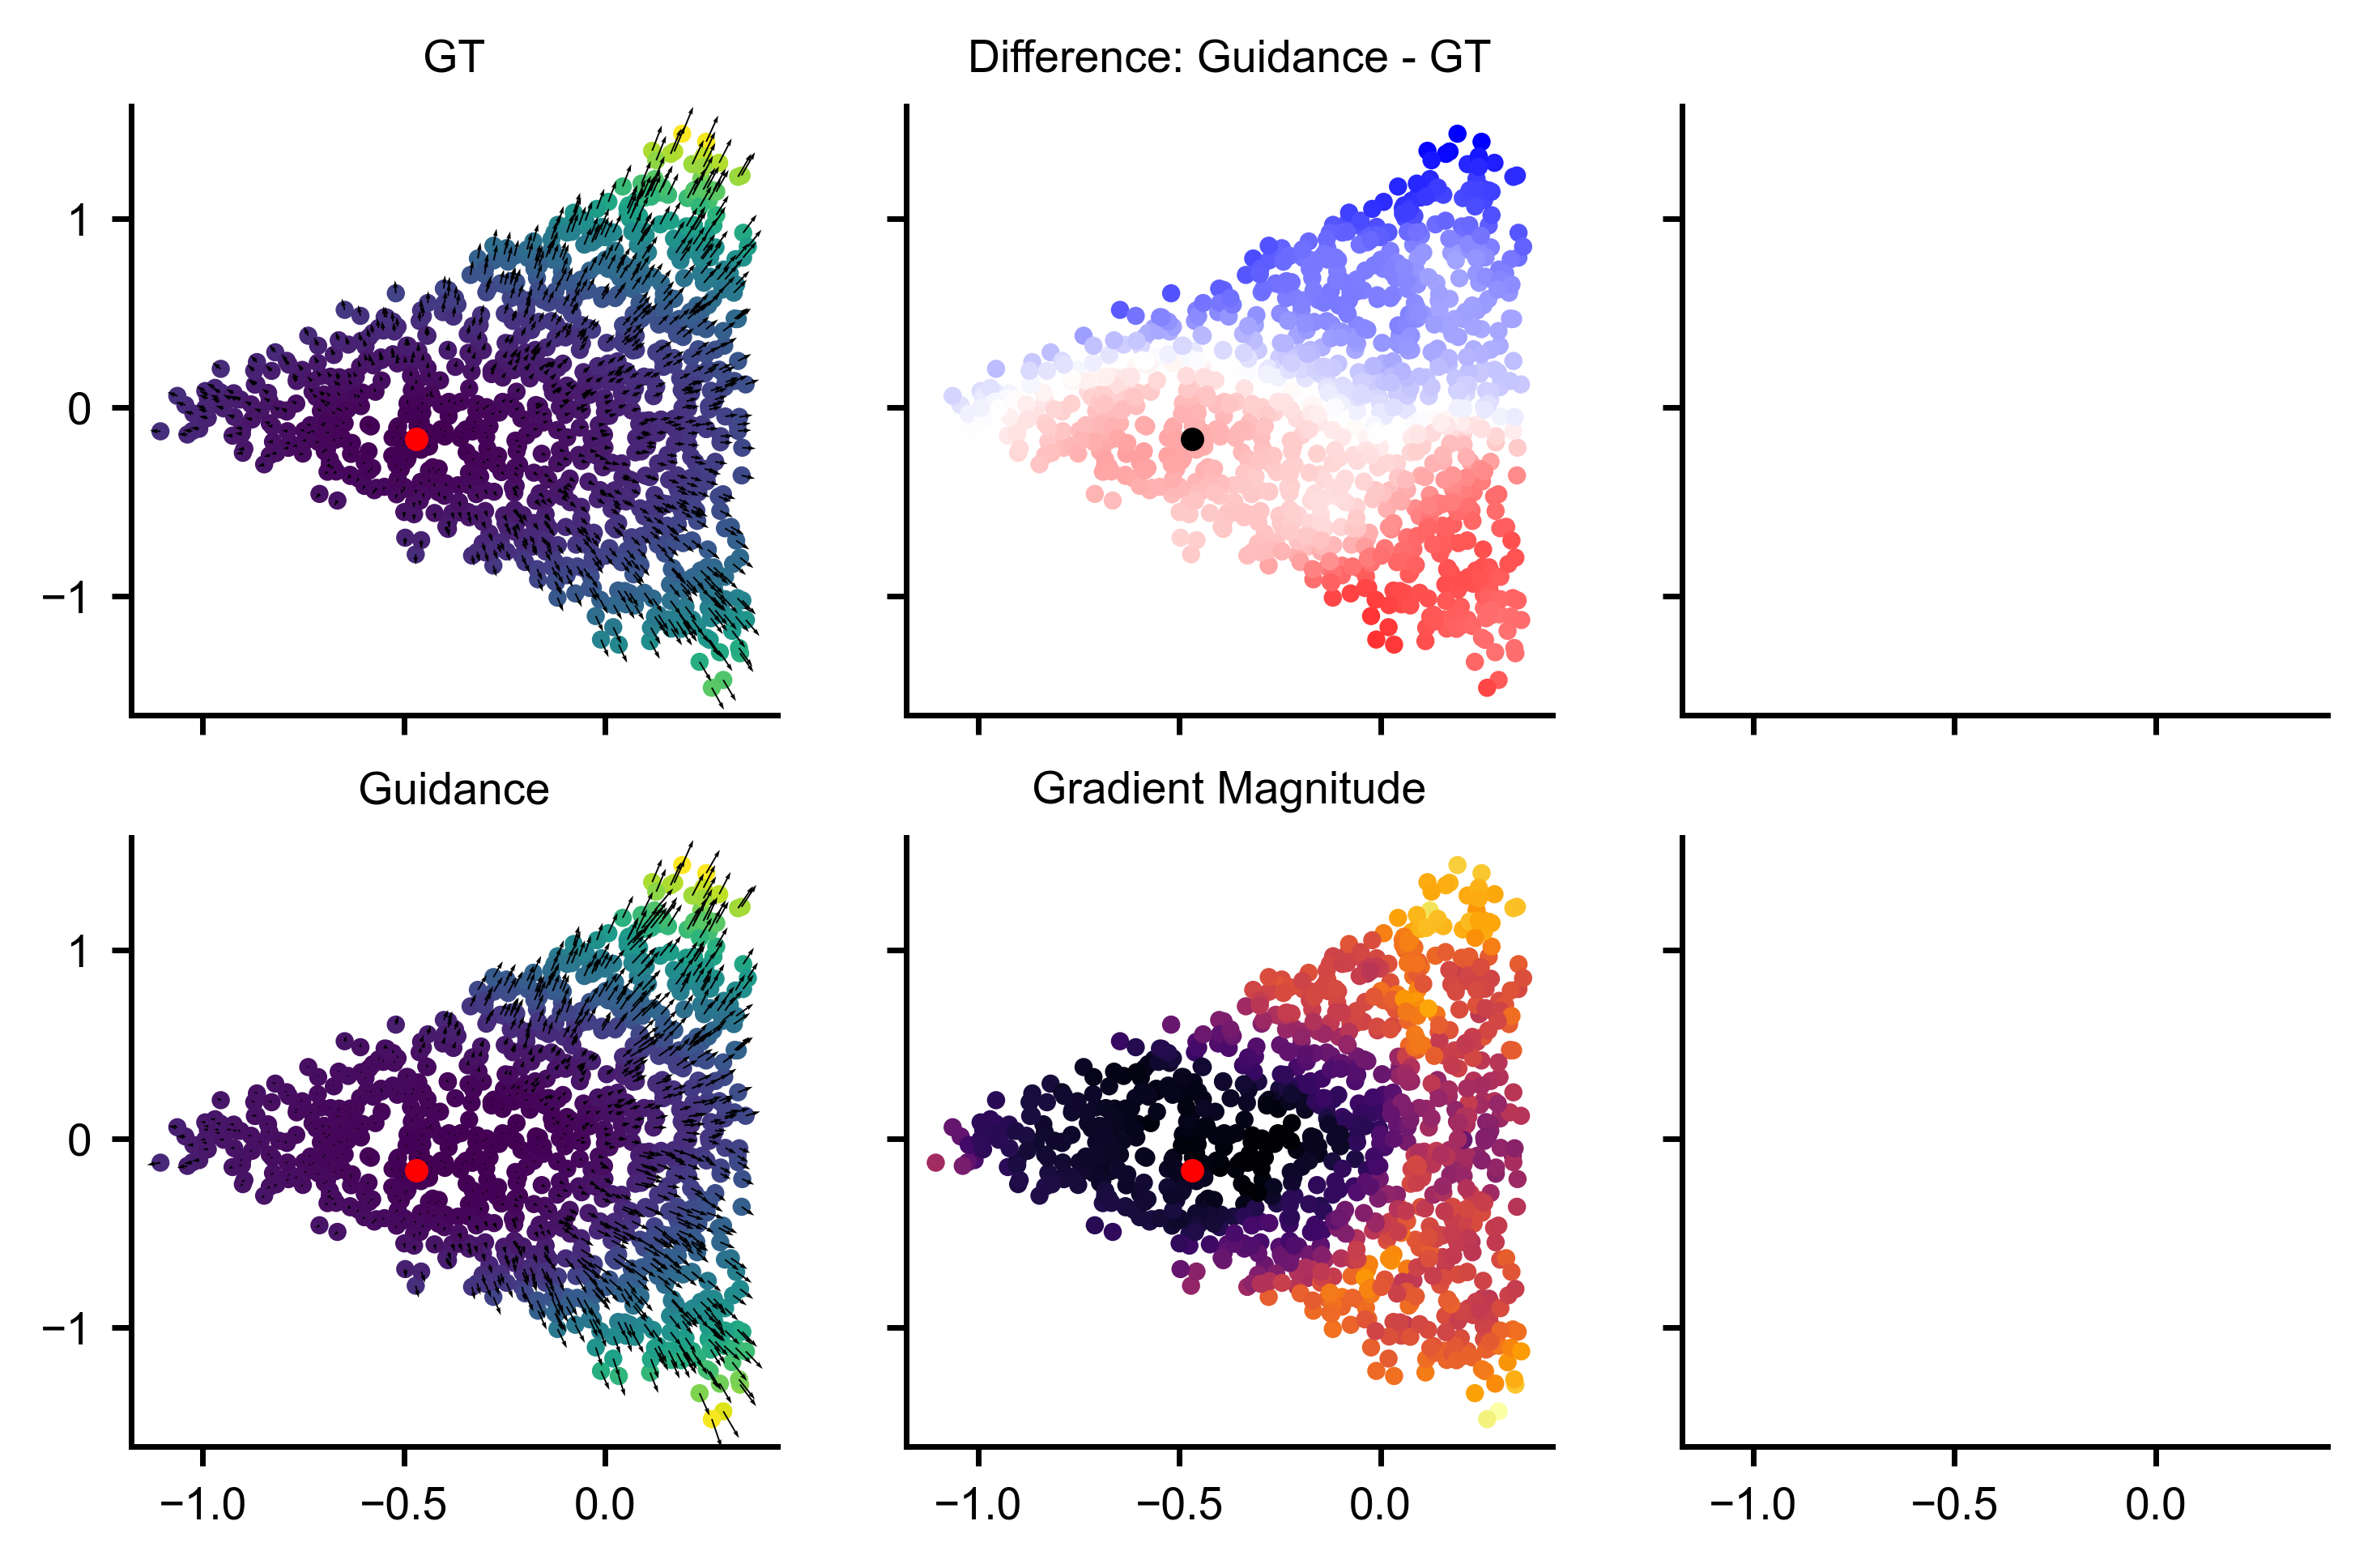

In [20]:
x, theta = load_specified_data("../data/two_moons_1000.pt")
dist_matrix = compute_distances(mse_dist, x, x)
gt_gradient = compute_distances(lambda x, y: 2 * (x - y), x, x)
idx = 9
T = 0

pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta[[idx]], x, guidance, T)
fig, _ = plot_guidance_analytics_2D(
    x,
    x[idx],
    dist_matrix[idx],       
    pred_dist.squeeze(),
    x_grad,
    gt_gradient[idx],
    f"Two Moons: Observation space\n{T =}",
)
fig.savefig("figures/guidance_eval_tow_moons_obs_space.png")
    
plot_corr(dist_matrix[idx], pred_dist, x_grad)

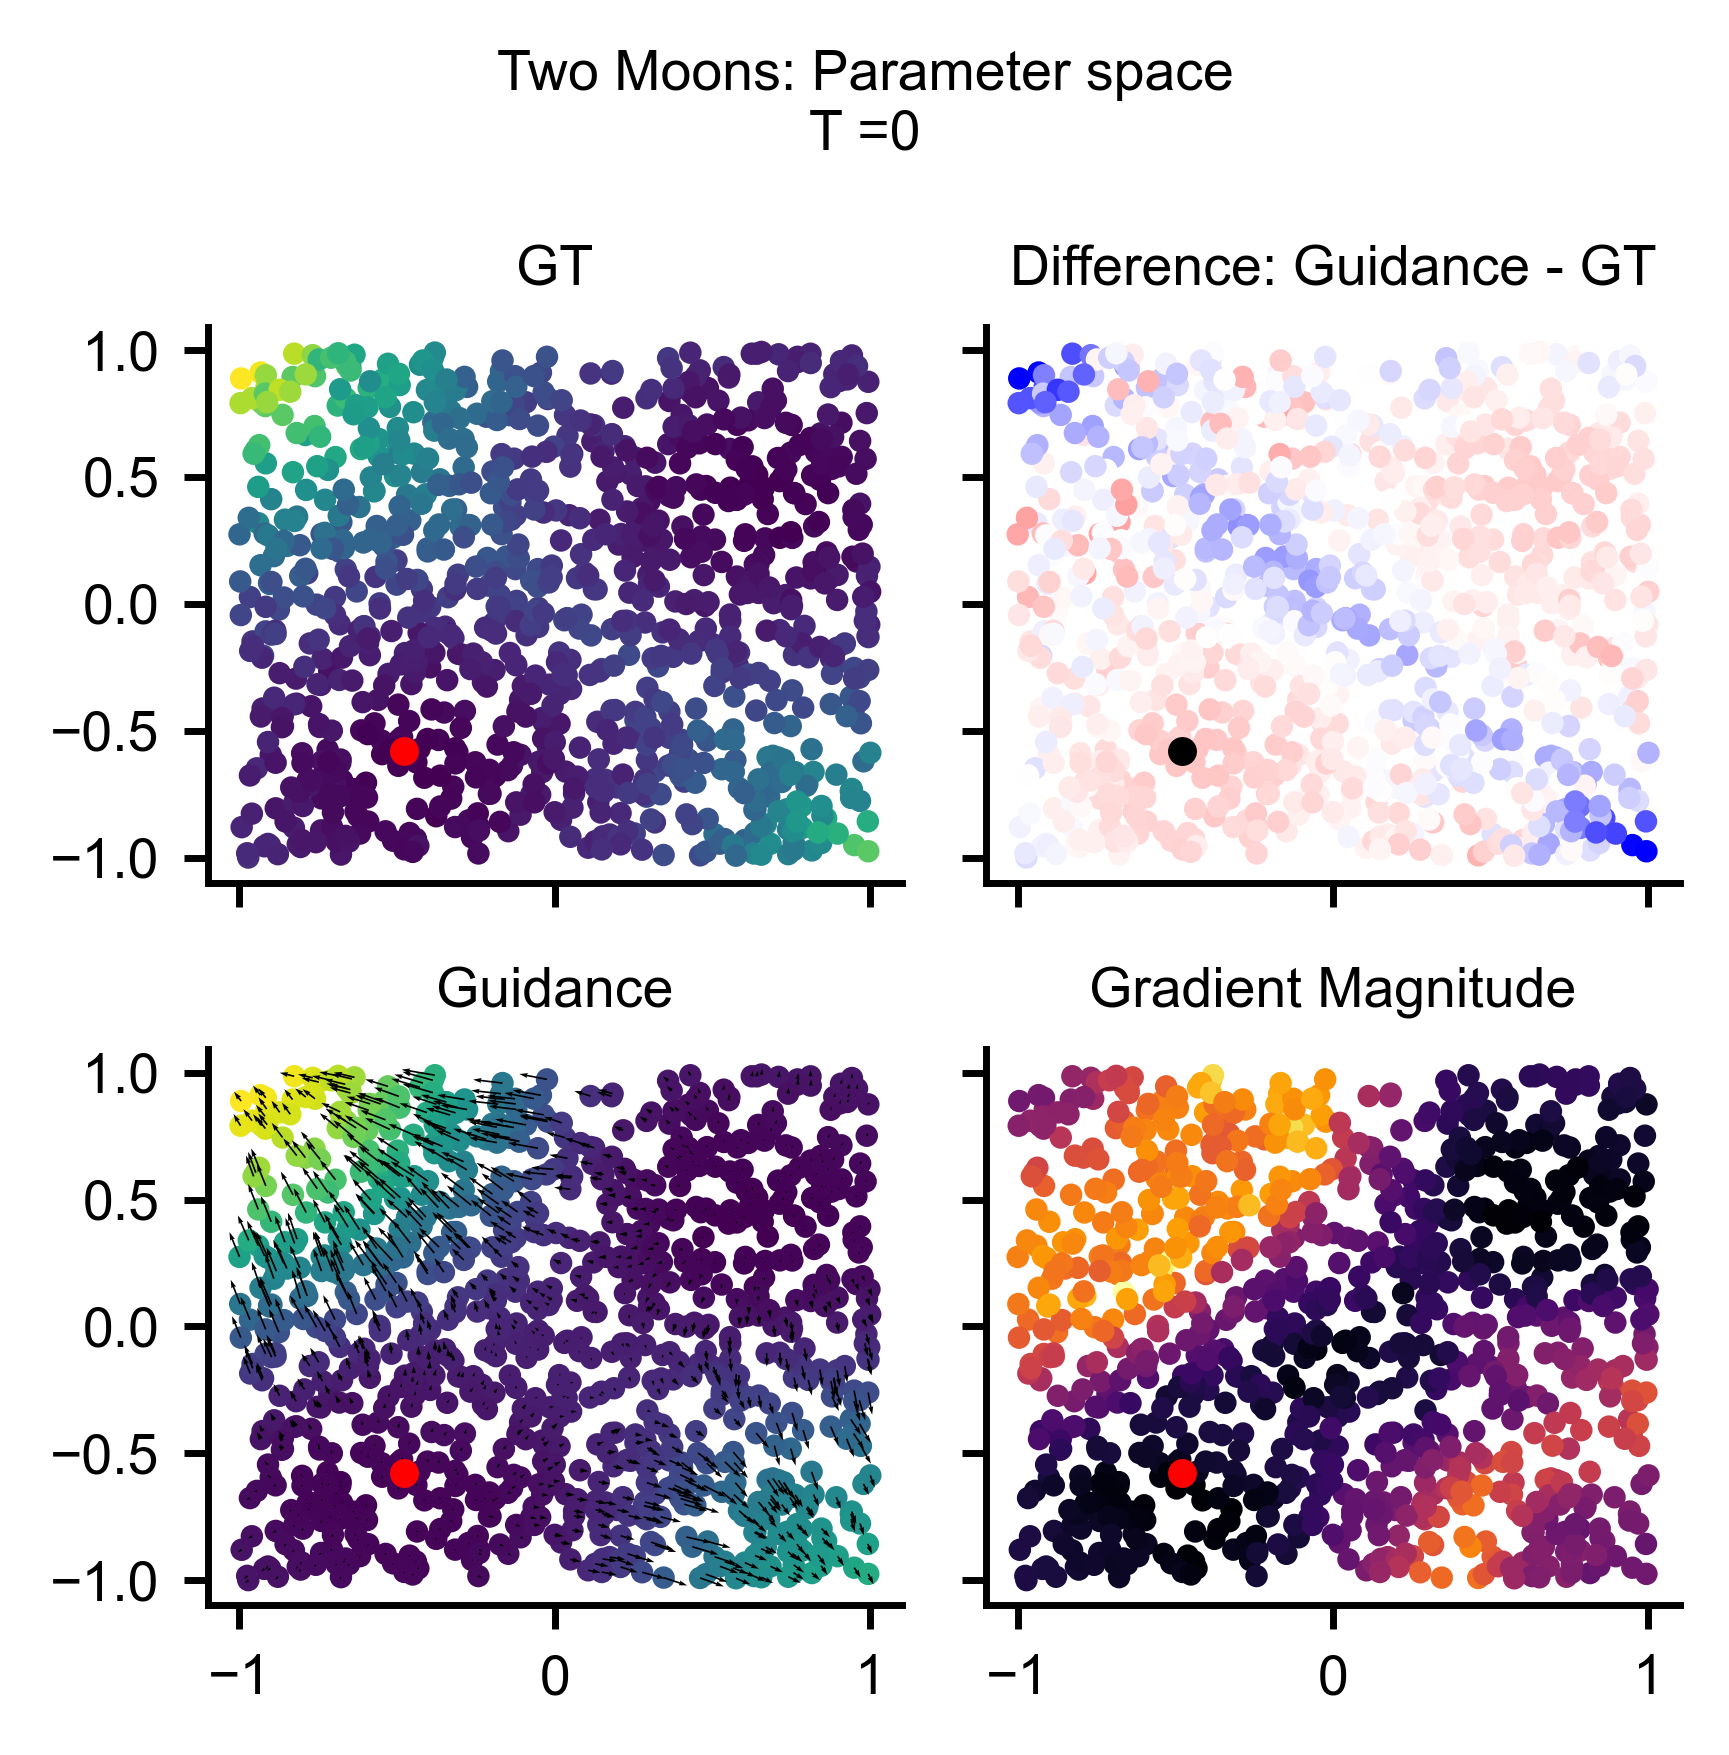

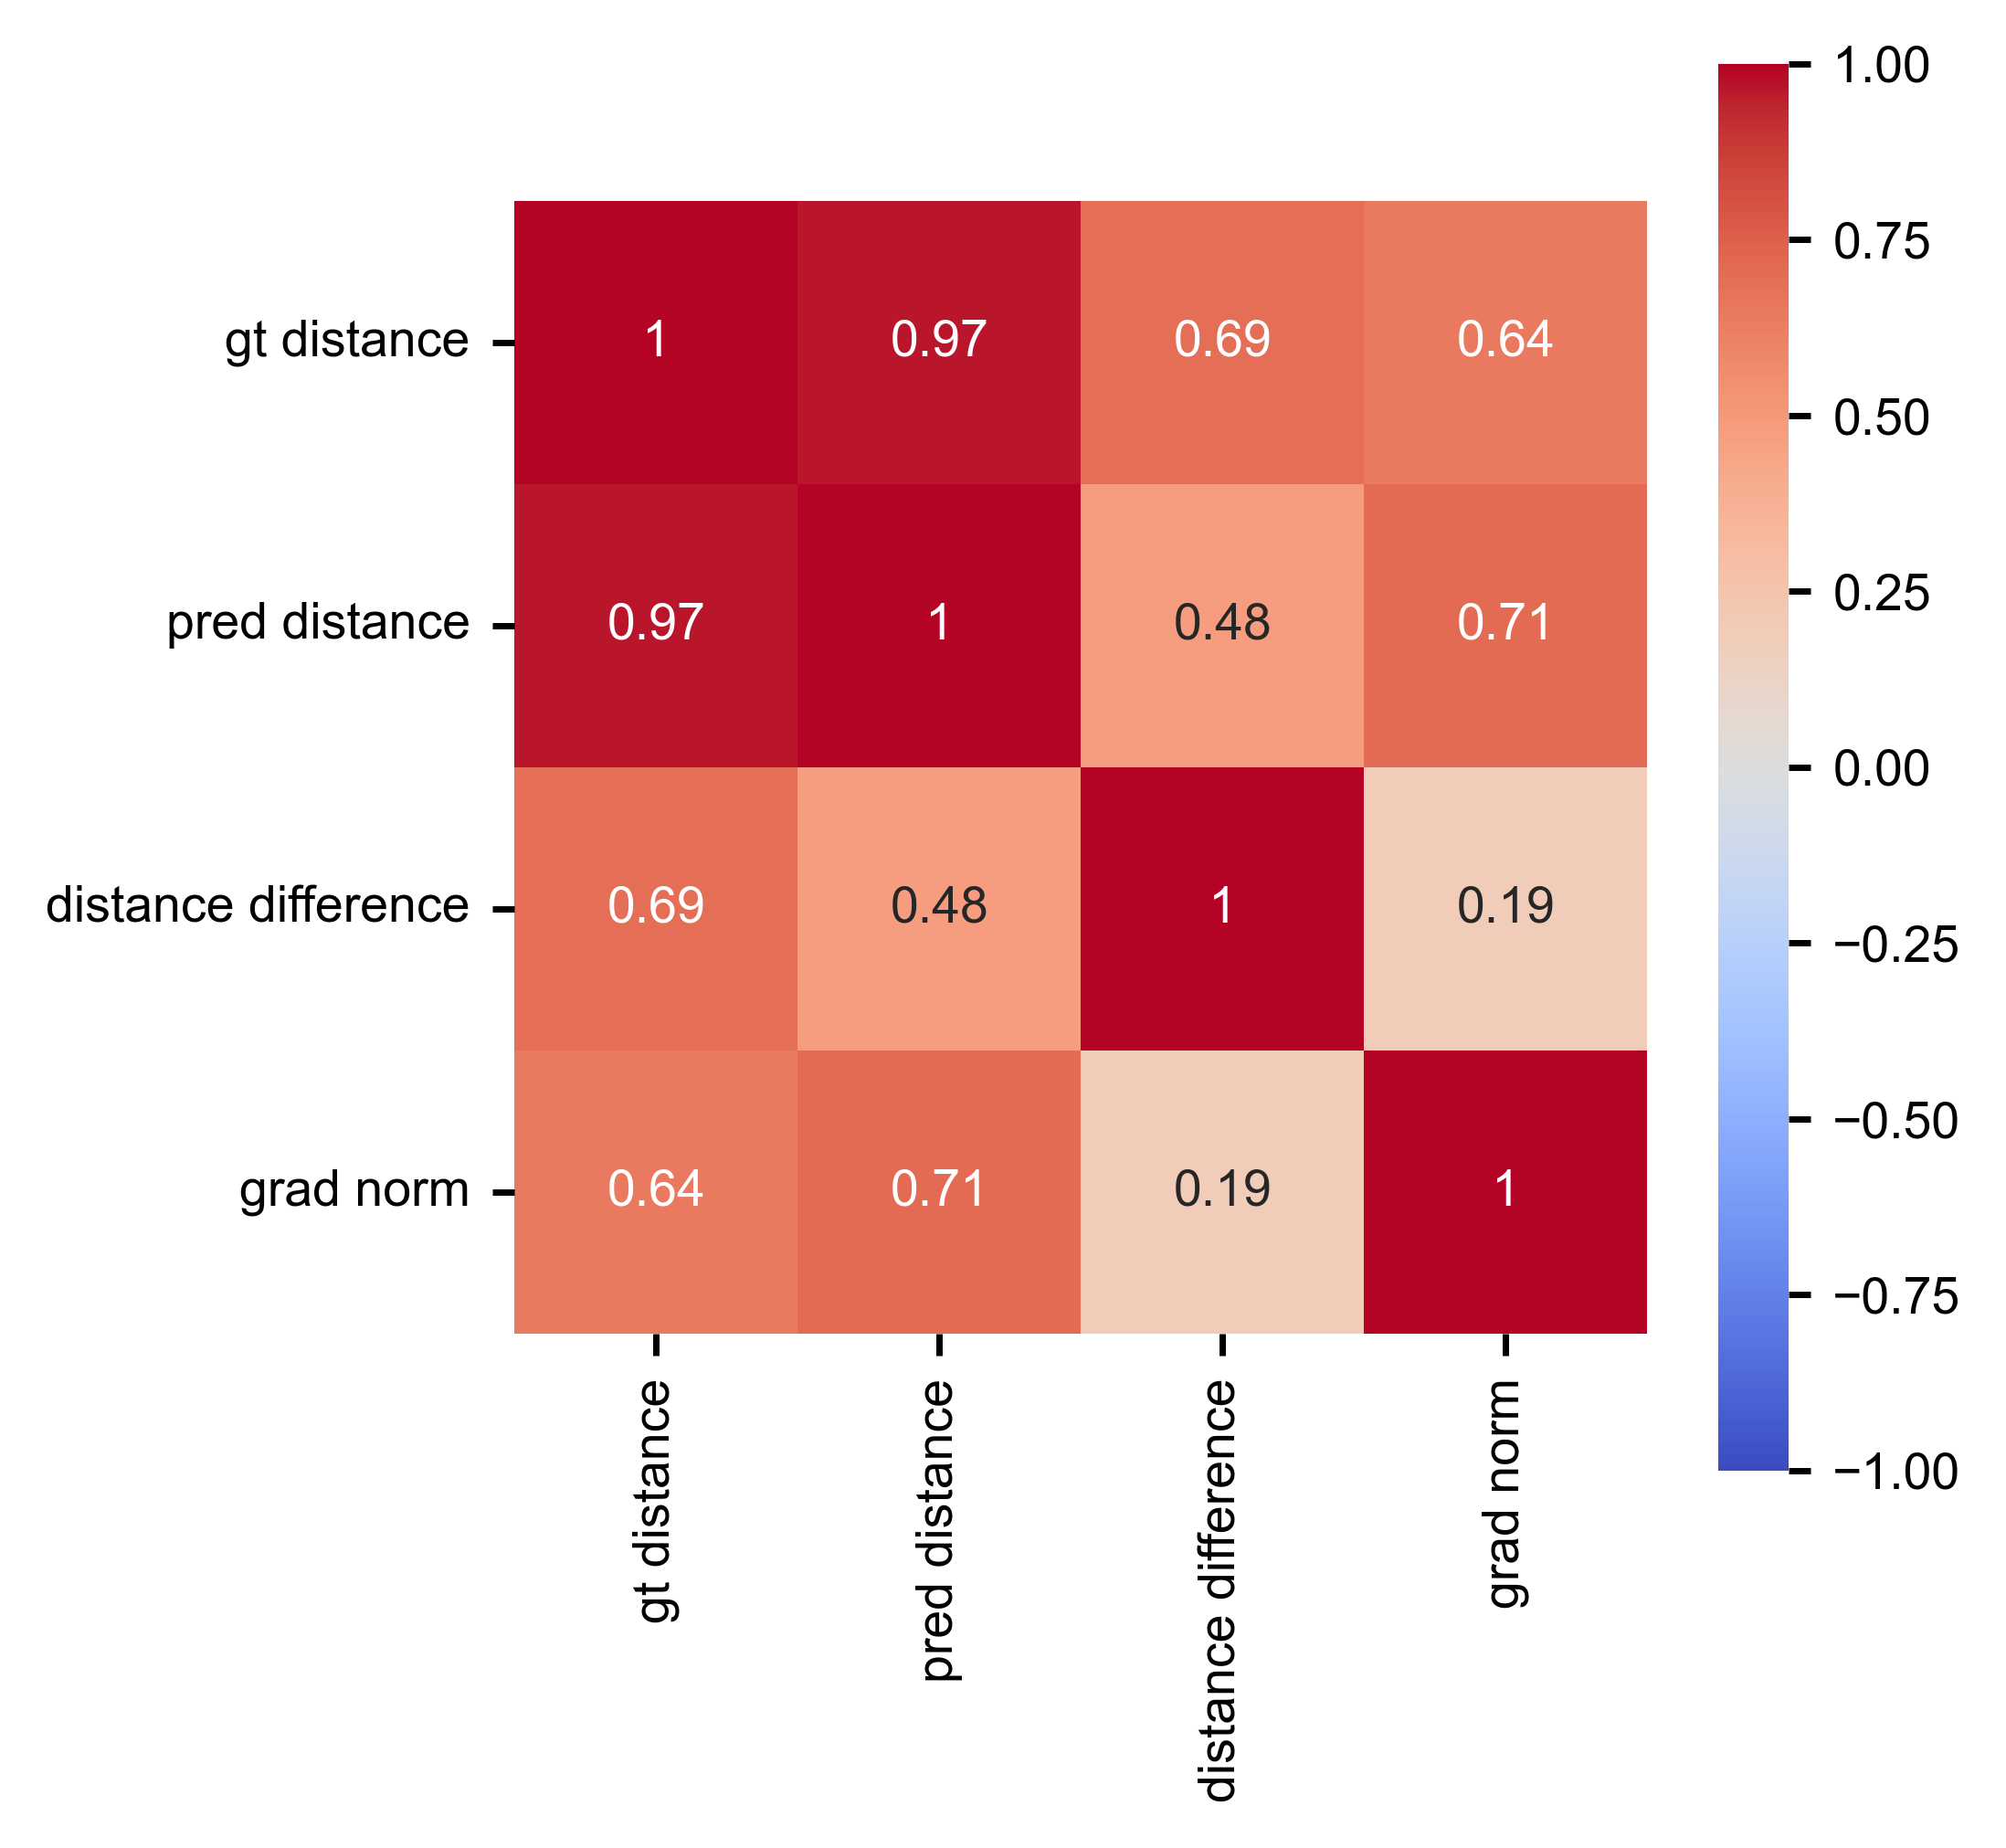

In [21]:
pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta, x[[idx]], guidance, T)
fig, _ = plot_guidance_analytics_2D(
    theta,
    theta[idx],
    dist_matrix[idx],
    pred_dist.squeeze(),
    theta_grad,
    title=f"Two Moons: Parameter space\n{T =}",
)
fig.savefig("figures/guidance_eval_tow_moons_param_space.png")
plot_corr(dist_matrix[idx], pred_dist, theta_grad)

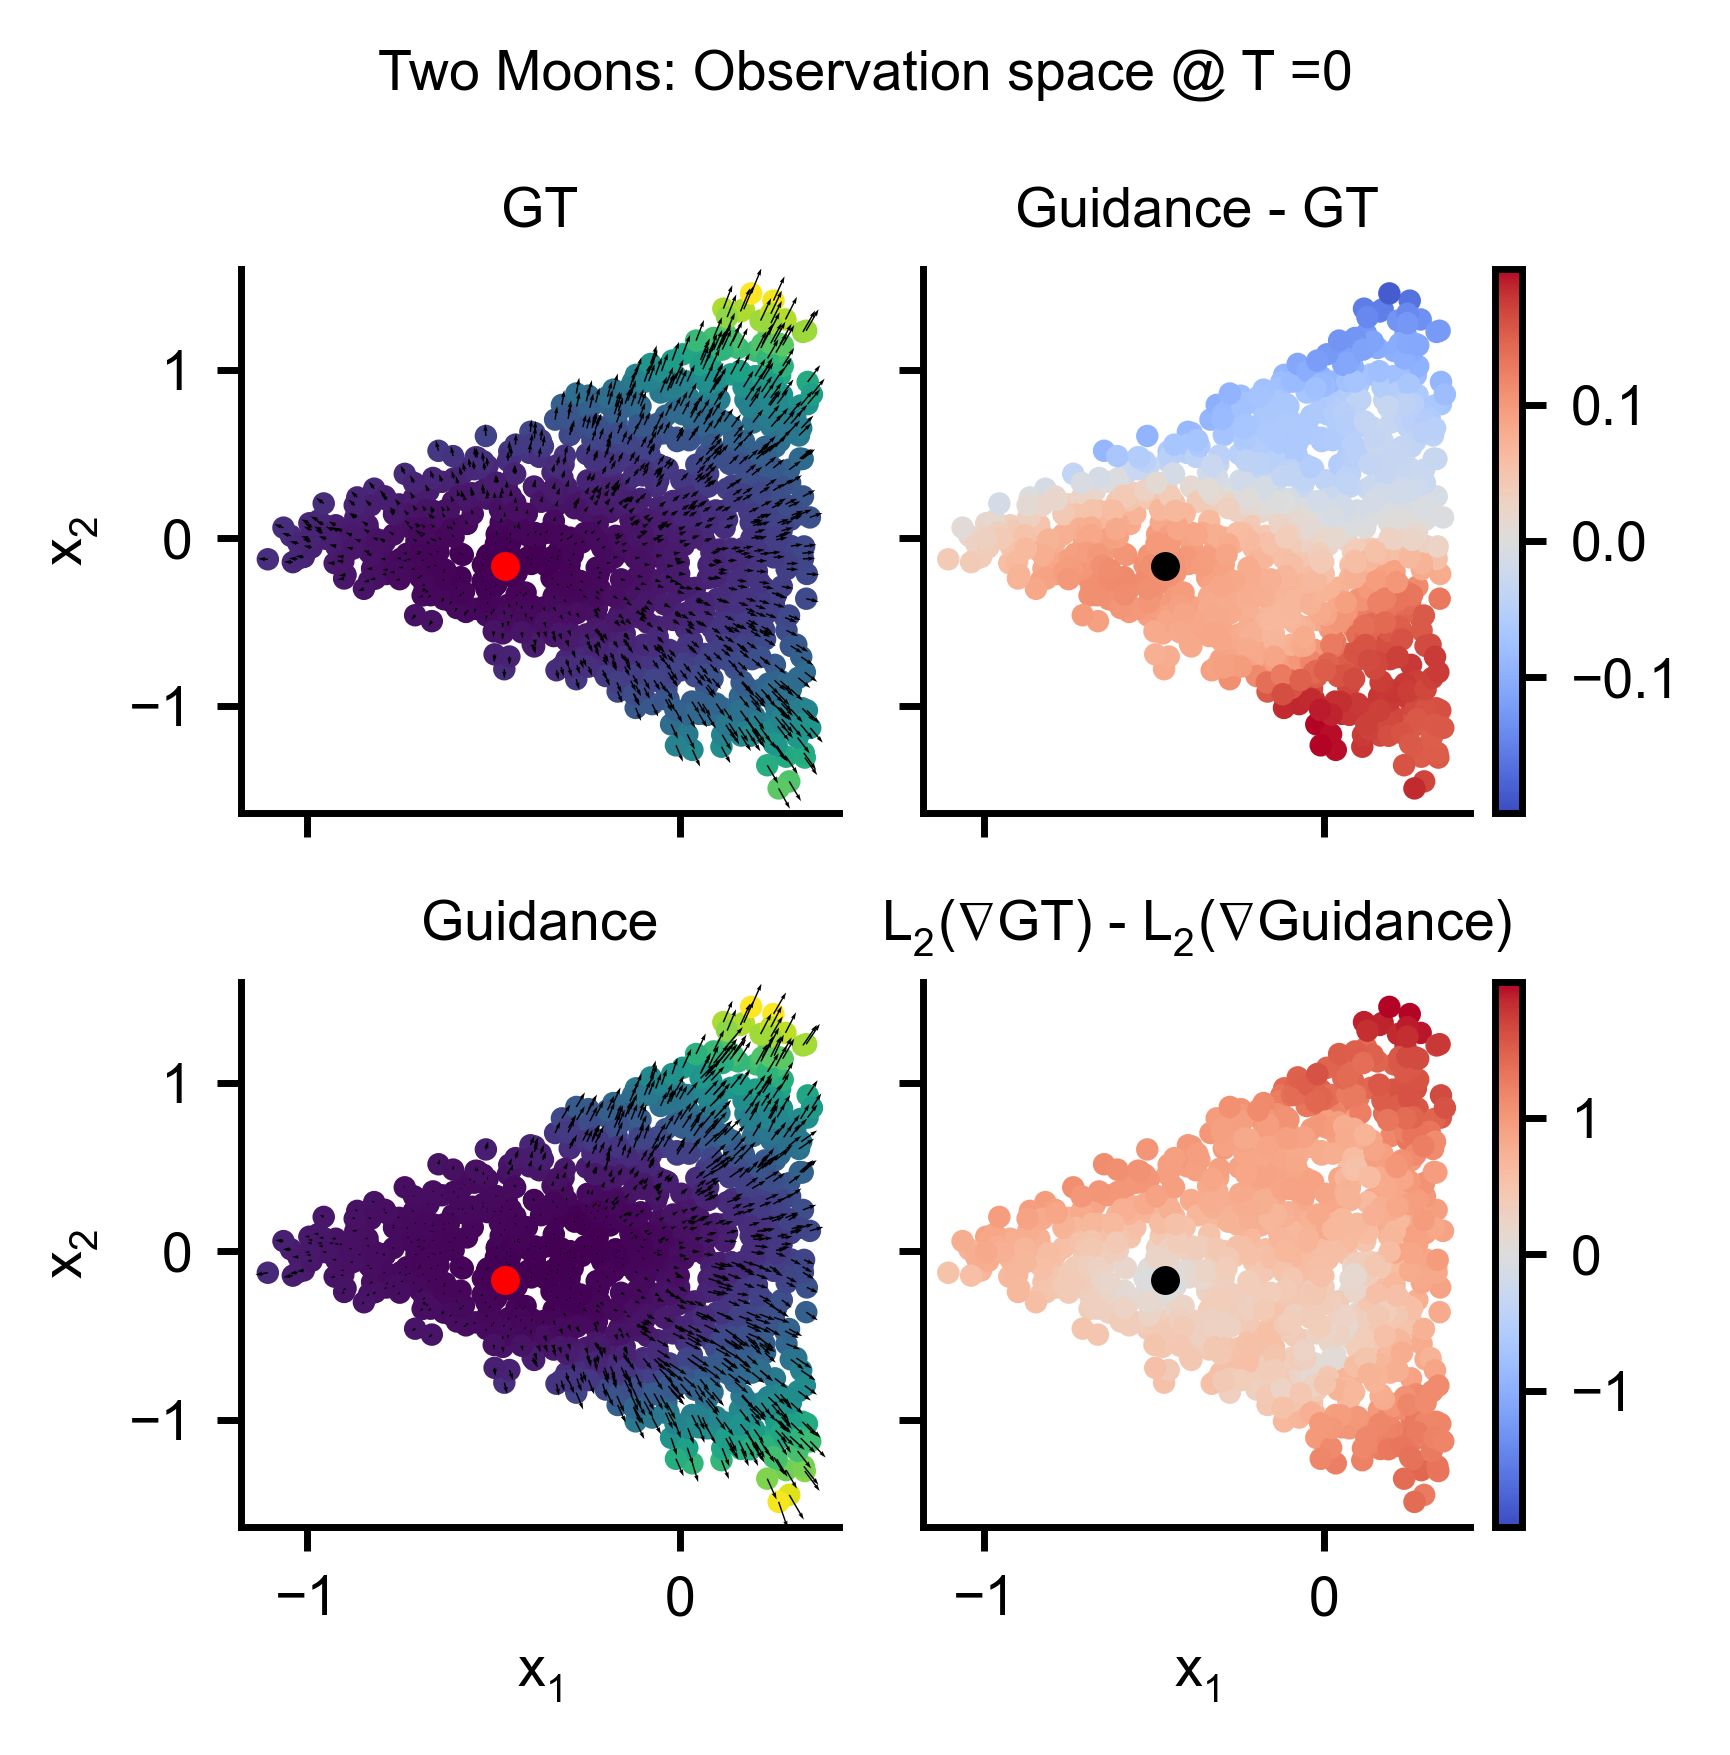

In [22]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


def create_asymmetric_colormap(vmin, vmax, vcenter, cmap_name="coolwarm"):
    """
    Creates an asymmetric colormap by adjusting the normalization so that colors are squished based on asymmetry.

    Parameters:
    vmin (float): Minimum data value.
    vmax (float): Maximum data value.
    vcenter (float): Center value for asymmetry.
    cmap_name (str): Name of the base colormap.

    Returns:
    colormap, norm: The modified colormap and normalization.
    """

    # Get original colormap
    cmap = plt.get_cmap(cmap_name)

    # Define asymmetry
    lower_portion = (vcenter - vmin) / (vmax - vmin)
    upper_portion = (vmax - vcenter) / (vmax - vmin)

    # Create new color mapping
    if lower_portion < upper_portion:
        # More space above center (squish lower part)
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    else:
        # More space below center (squish upper part)
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    return cmap, norm


def plot_guidance_analytics_2D_minimal(
    samples: Tensor,
    gt_sample: Tensor,
    gt_distance: Tensor,
    pred_distance: Tensor,
    pred_grad: Tensor,
    gt_grad: Tensor = None,
    title: str = "",
):
    fig, axs = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(3.5, 3.5))
    ((ax1, ax2), (ax3, ax4)) = axs

    grad_norm = torch.linalg.norm(pred_grad, dim=-1)
    if len(pred_grad.shape) == 3:
        gt_sample = gt_sample.mean(0)
        samples = samples.mean(1)
        pred_grad = pred_grad.mean(1)
        grad_norm = grad_norm.mean(-1)

    ax1.scatter(*samples.T, c=gt_distance, s=5)
    if gt_grad is not None:
        ax1.quiver(*samples.T, *gt_grad.T)
    ax1.scatter(*gt_sample, c="r", s=10)
    ax1.set_title("GT")

    difference = pred_distance - gt_distance
    scatter = ax2.scatter(
        *samples.T,
        c=difference,
        cmap="coolwarm",
        norm=mcolors.CenteredNorm(),
        s=5,
    )
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(scatter, cax=cax, orientation="vertical")
    ax2.scatter(*gt_sample, c="k", s=10)
    ax2.set_title("Guidance - GT")

    ax3.scatter(*samples.T, c=pred_distance, s=5)
    ax3.quiver(*samples.T, *pred_grad.T)
    ax3.scatter(*gt_sample, c="r", s=10)
    ax3.set_title("Guidance")

    gt_grad_norm = torch.linalg.norm(gt_grad, dim=-1)
    difference = gt_grad_norm - grad_norm
    scatter = ax4.scatter(
        *samples.T, c=difference, norm=mcolors.CenteredNorm(), cmap="coolwarm", s=5
    )
    ax4.scatter(*gt_sample, c="k", s=10)
    ax4.set_title(r"$L_2(\nabla$GT$)$ - $L_2(\nabla$Guidance$)$")
    divider = make_axes_locatable(ax4)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(scatter, cax=cax, orientation="vertical")

    fig.suptitle(title)
    fig.tight_layout()
    return fig, axs


pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta[[idx]], x, guidance, T)
fig, axs = plot_guidance_analytics_2D_minimal(
    x,
    x[idx],
    dist_matrix[idx],
    pred_dist.squeeze(),
    x_grad,
    gt_gradient[idx],
    f"Two Moons: Observation space @ {T =}",
)
axs[0, 0].set_ylabel(r"$x_2$")
axs[1, 0].set_ylabel(r"$x_2$")
axs[1, 0].set_xlabel(r"$x_1$")
axs[1, 1].set_xlabel(r"$x_1$")
fig.tight_layout()
fig.savefig("./figures/guidance_eval_two_moons_obs_space_minimal.pdf")

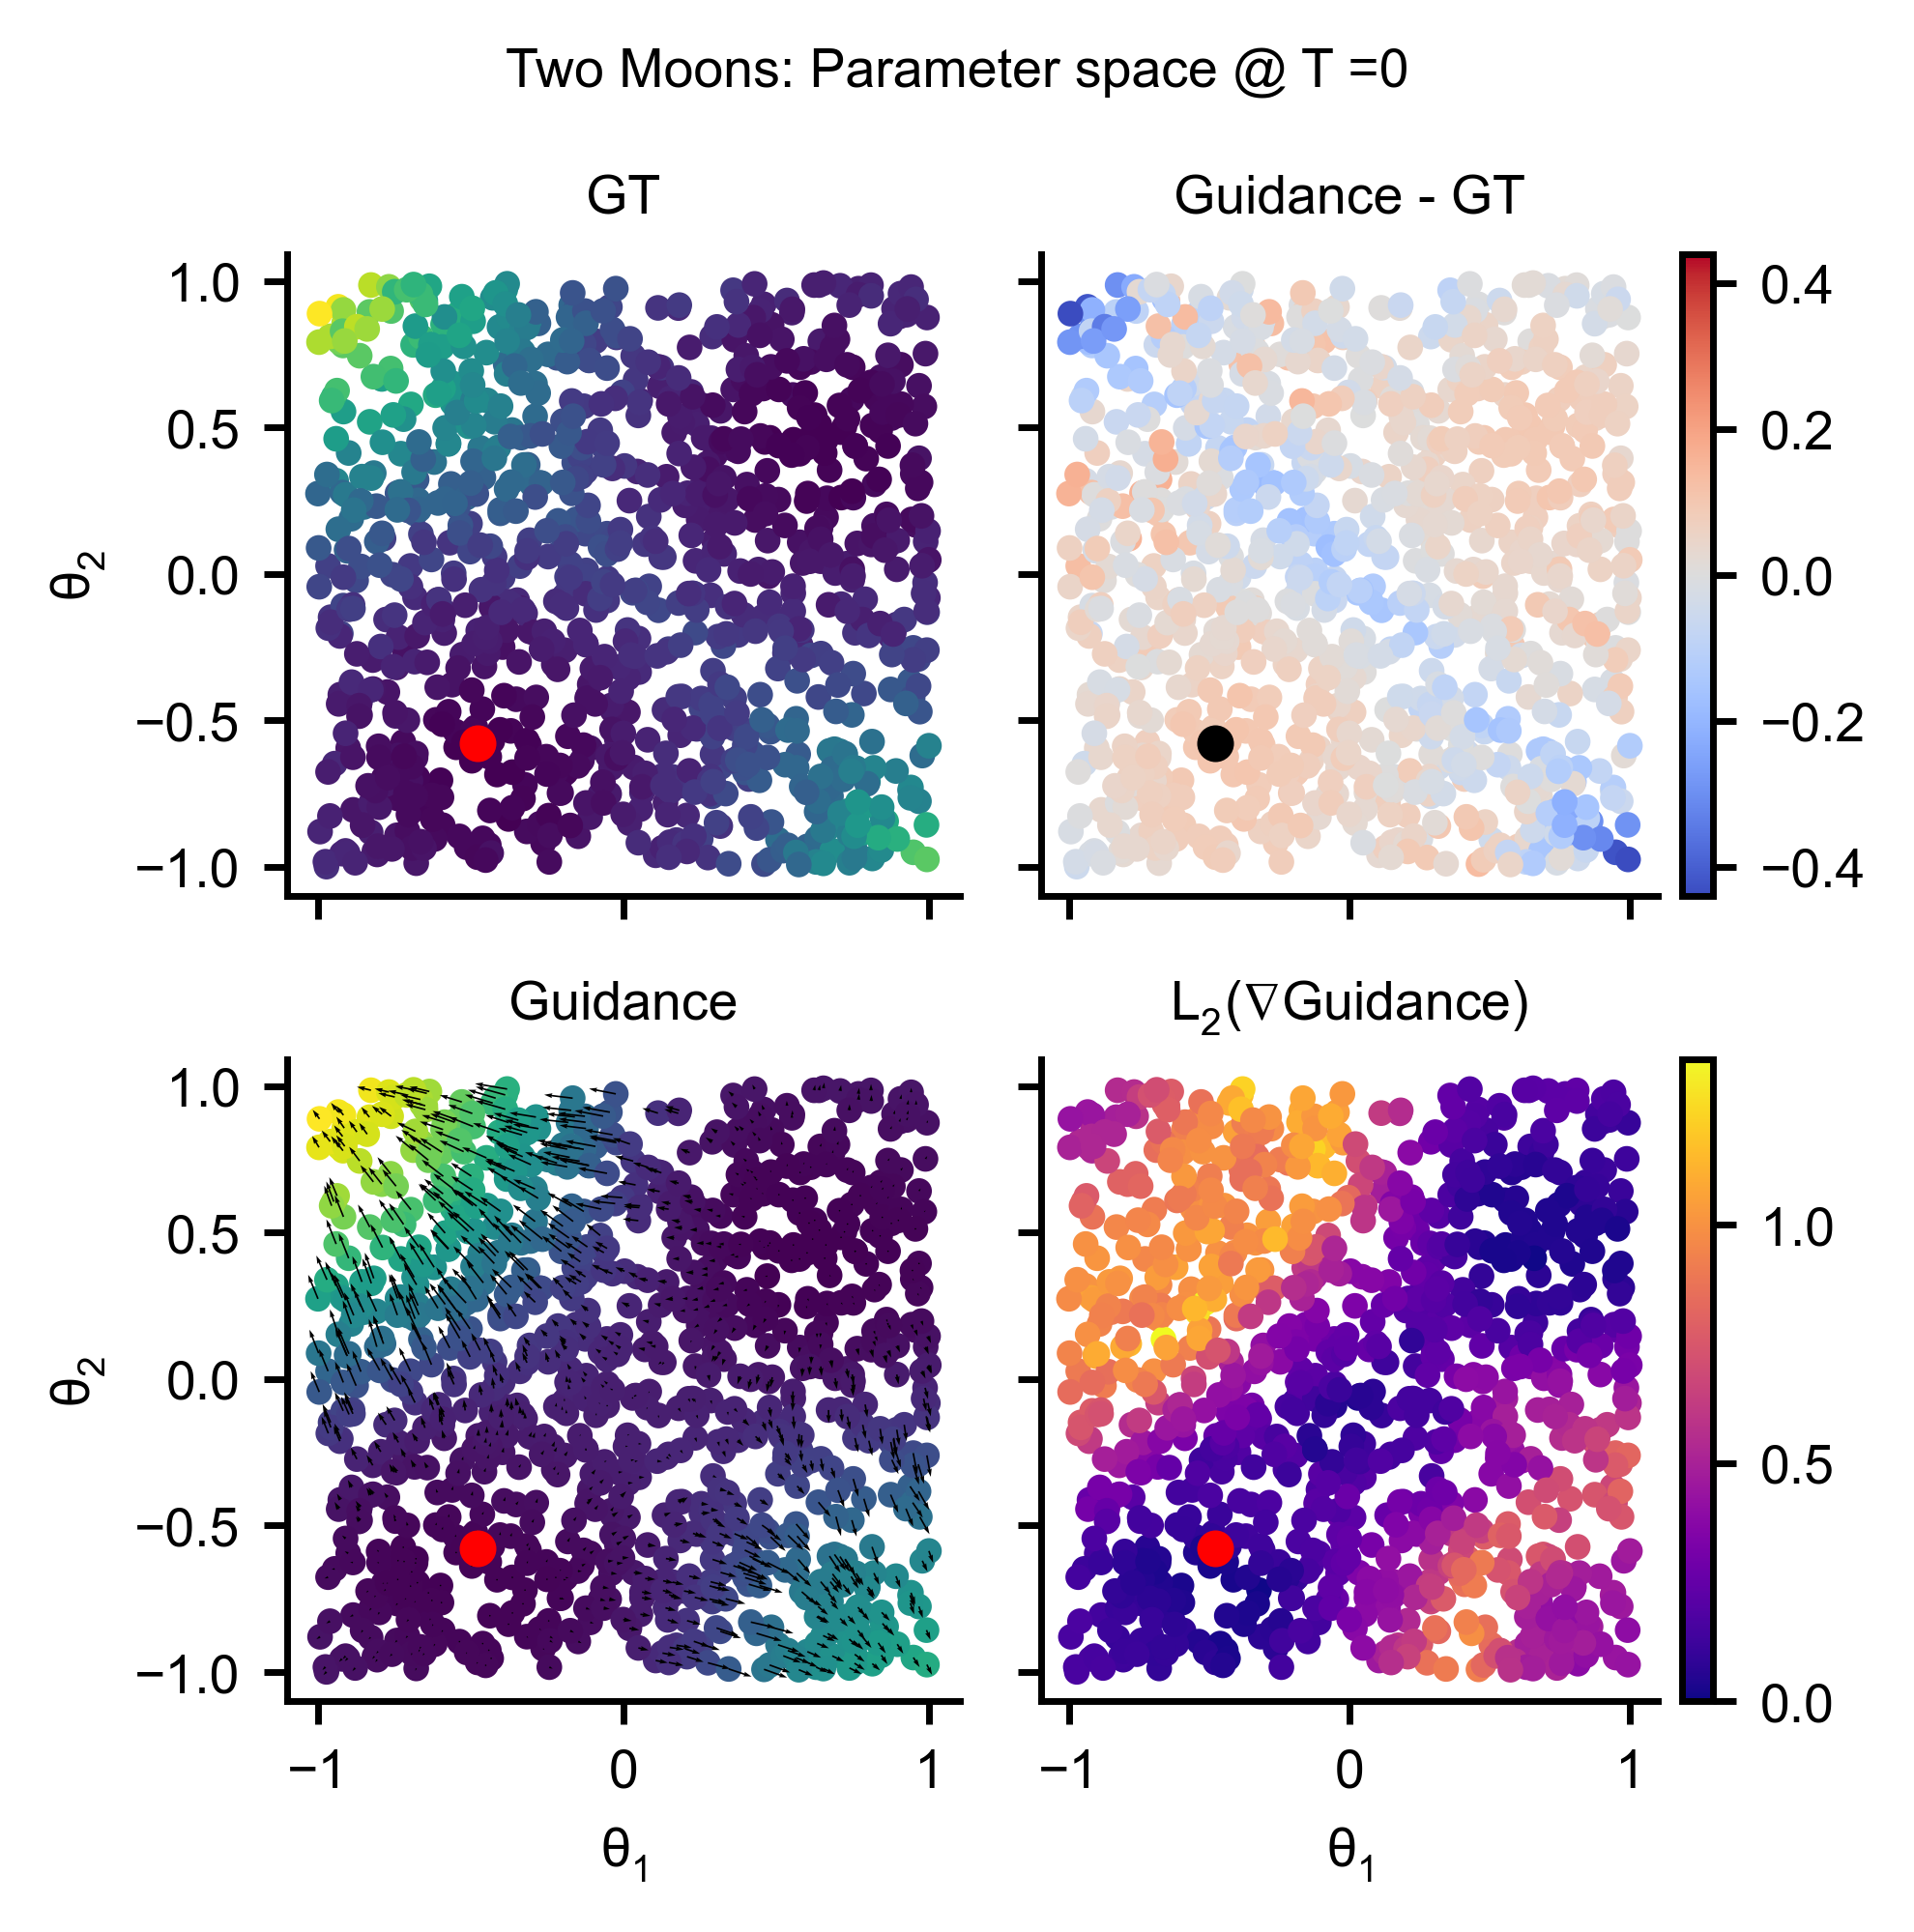

In [23]:
def plot_guidance_analytics_2D_param_space(
    samples: Tensor,
    gt_sample: Tensor,
    gt_distance: Tensor,
    pred_distance: Tensor,
    pred_grad: Tensor,
    gt_grad: Tensor = None,
    title: str = "",
):
    fig, axs = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(4, 4))
    ((ax1, ax2), (ax3, ax4)) = axs

    grad_norm = torch.linalg.norm(pred_grad, dim=-1)
    if len(pred_grad.shape) == 3:
        gt_sample = gt_sample.mean(0)
        samples = samples.mean(1)
        pred_grad = pred_grad.mean(1)
        grad_norm = grad_norm.mean(-1)

    ax1.scatter(*samples.T, c=gt_distance, s=8)
    if gt_grad is not None:
        ax1.quiver(*samples.T, *gt_grad.T)
    ax1.scatter(*gt_sample, c="r", s=20)
    ax1.set_title("GT")

    difference = pred_distance - gt_distance
    scatter = ax2.scatter(
        *samples.T,
        c=difference,
        cmap="coolwarm",
        norm=mcolors.CenteredNorm(),
        s=8,
    )
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(scatter, cax=cax, orientation="vertical")
    ax2.scatter(*gt_sample, c="k", s=20)
    ax2.set_title("Guidance - GT")

    ax3.scatter(*samples.T, c=pred_distance, s=8)
    ax3.quiver(*samples.T, *pred_grad.T)
    ax3.scatter(*gt_sample, c="r", s=20)
    ax3.set_title("Guidance")

    scatter = ax4.scatter(*samples.T, c=grad_norm, cmap="plasma", s=8, vmin=0)
    ax4.scatter(*gt_sample, c="red", s=20)
    ax4.set_title(r"$L_2(\nabla$Guidance$)$")
    divider = make_axes_locatable(ax4)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(scatter, cax=cax, orientation="vertical")

    fig.suptitle(title)
    fig.tight_layout()
    return fig, axs


pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta, x[[idx]], guidance, T)
fig, axs = plot_guidance_analytics_2D_param_space(
    theta,
    theta[idx],
    dist_matrix[idx],
    pred_dist.squeeze(),
    theta_grad,
    title=f"Two Moons: Parameter space @ {T =}",
)
axs[0, 0].set_ylabel(r"$\theta_2$")
axs[1, 0].set_ylabel(r"$\theta_2$")
axs[1, 0].set_xlabel(r"$\theta_1$")
axs[1, 1].set_xlabel(r"$\theta_1$")
fig.tight_layout()
fig.savefig("./figures/guidance_eval_two_moons_param_space_minimal.pdf")

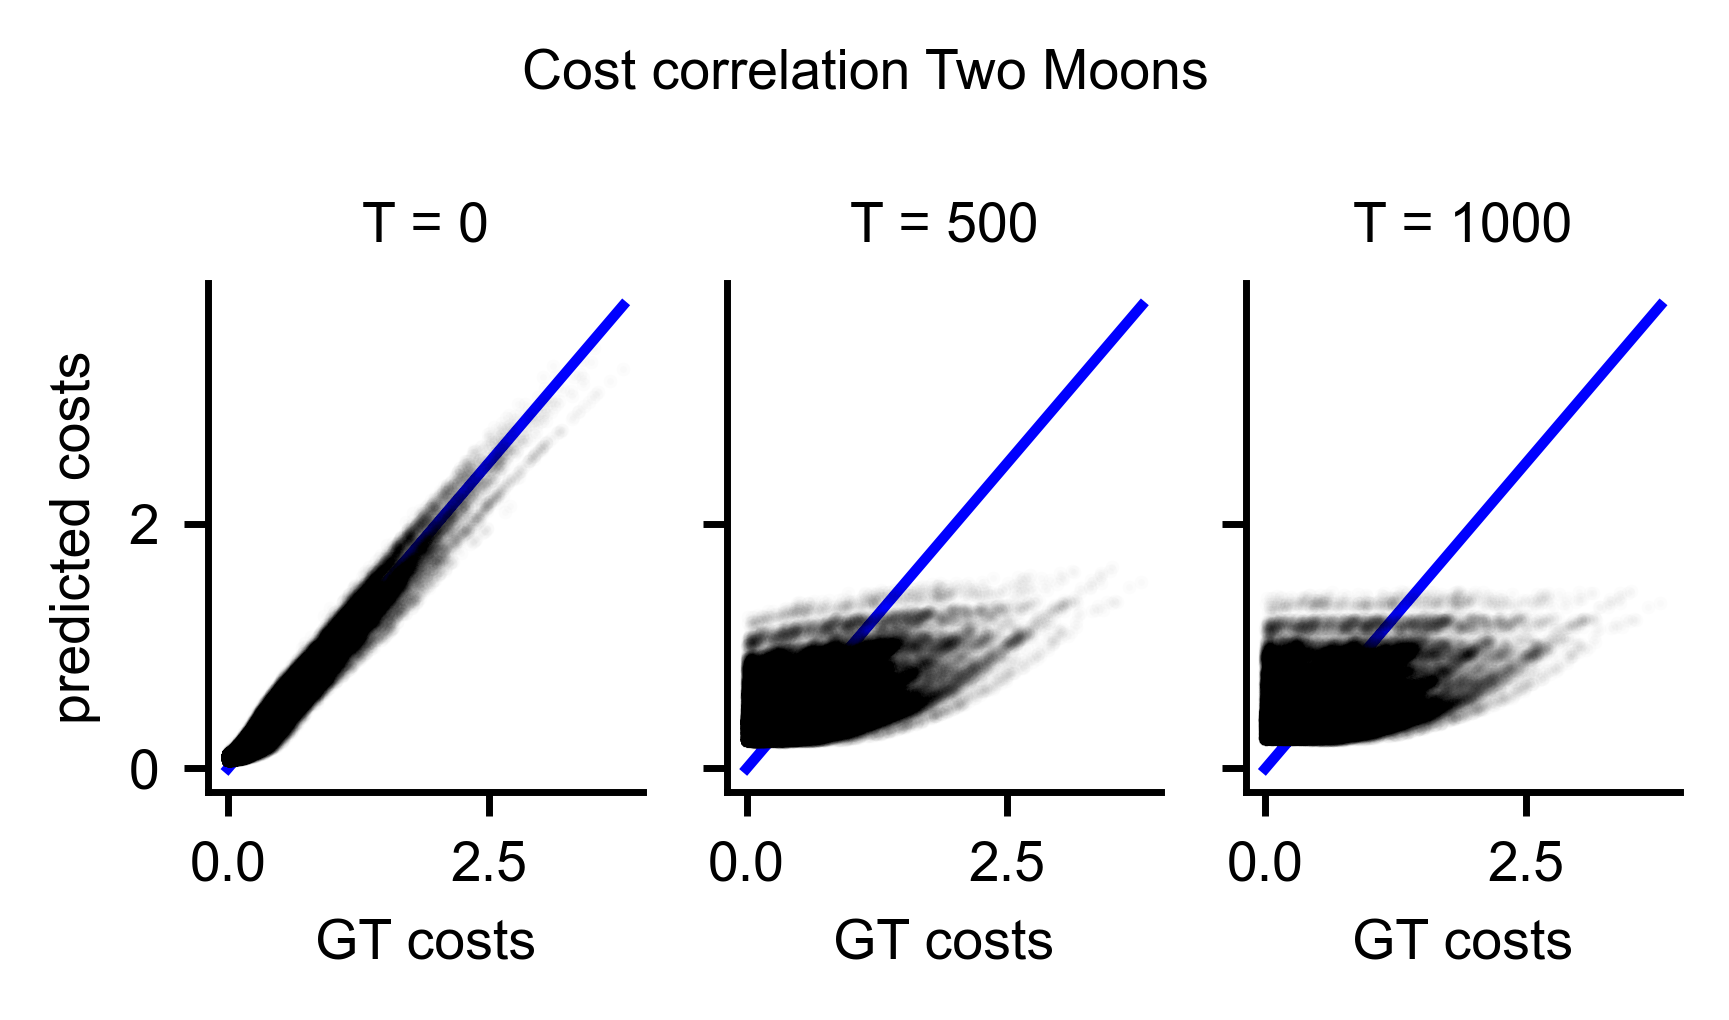

In [8]:
x, theta = load_specified_data("../data/two_moons_1000.pt")
indices = np.arange(100)
fig, axs = plt.subplots(ncols=3, figsize=(3.5, 2), sharex=True, sharey=True)


for T, ax in zip([0, 500, 1000], (axs)):
    with torch.no_grad():
        time_repr = guidance.get_diff_time_repr(np.ones(len(indices)) * T)
        pred_dist = guidance.forward(theta[[indices]], x[None].repeat(len(indices), 1, 1), time_repr)

    outer = torch.maximum(dist_matrix[indices].max(), pred_dist.max())
    ax.plot([0, outer], [0, outer], color="blue", zorder=-1)
    ax.scatter(dist_matrix[indices].flatten(), pred_dist[:, :, 0].flatten(), s=1, alpha=0.01)
    ax.set_title(f"{T = }")
    ax.set_xlabel("GT costs")

axs[0].set_ylabel("predicted costs")
fig.suptitle("Cost correlation Two Moons")  
fig.tight_layout()
fig.savefig("figures/guidance_eval_cost_corr_two_moons.pdf")


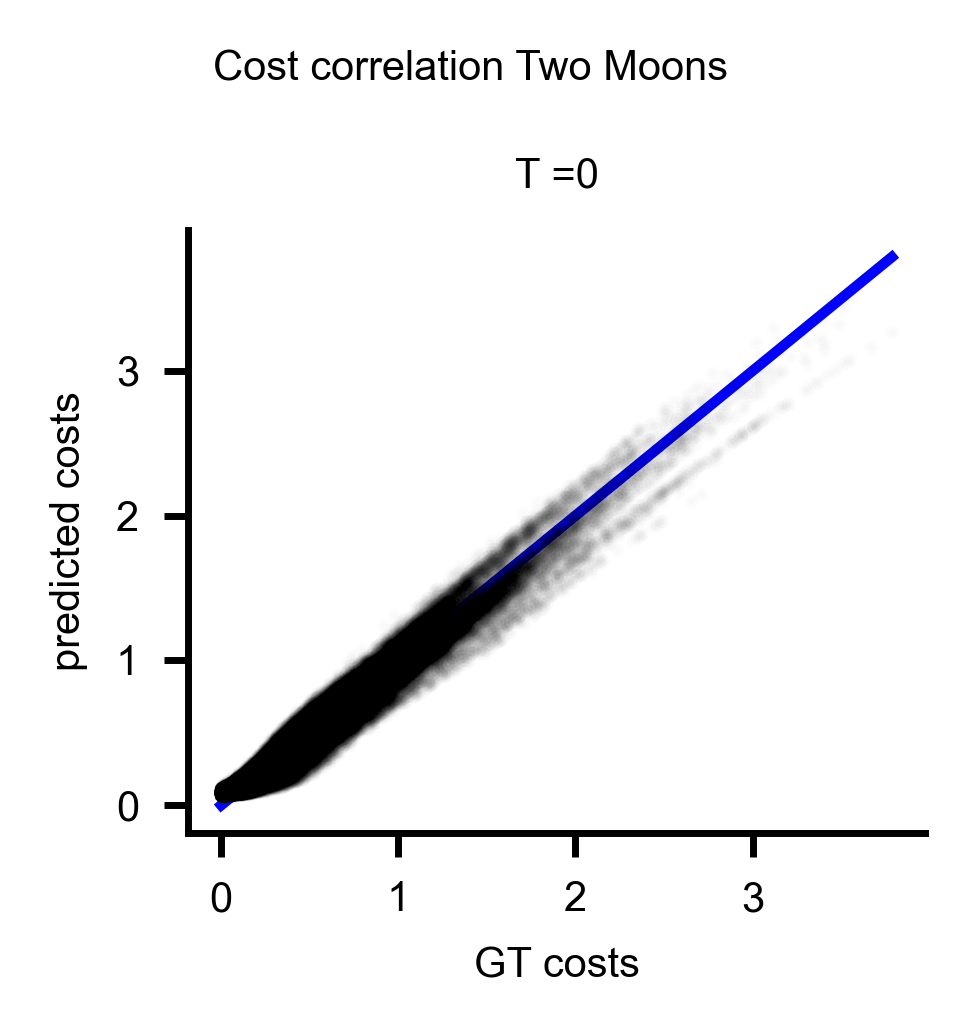

In [ ]:
indices = np.arange(100)
fig, ax = plt.subplots(figsize=(2, 2), sharex=True, sharey=True)


with torch.no_grad():
    time_repr = guidance.get_diff_time_repr(np.ones(len(indices)) * 0)
    pred_dist = guidance.forward(theta[[indices]], x[None].repeat(len(indices), 1, 1), time_repr)

outer = torch.maximum(dist_matrix[indices].max(), pred_dist.max())
ax.plot([0, outer], [0, outer], color="blue", zorder=-1)
ax.set_xlim([-outer * 0.05, outer * 1.05])
ax.set_ylim([-outer * 0.05, outer * 1.05])
ax.scatter(dist_matrix[indices].flatten(), pred_dist[:, :, 0].flatten(), s=1, alpha=0.01)
ax.set_title("T =0")
ax.set_xlabel("GT costs")
# ax.set_aspect("equal")
ax.set_ylabel("predicted costs")
fig.suptitle("Cost correlation Two Moons")  
fig.tight_layout()
fig.savefig("figures/guidance_eval_cost_corr_two_moons_T_0.png")


In [10]:
diffusion_ckpt = "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_denoiser/two_moons/2025-04-03-09-22-40/lightning_logs/version_0/epoch=99-step=4000.ckpt"

config: Config = Config.from_file("../config/sampling_diffusion.yaml")
sampler = DiffusionSampler(
    diffusion_ckpt, res_net_guidance_ckpt, config.observed_data_file, config.beta, False, extended_information=True
)

In [25]:
betas = np.array([10, 100, 200, 400])
n_samples = 1000
samples = np.zeros((len(betas), n_samples, sampler.theta_dim))
p = np.zeros(
    (
        len(betas),
        n_samples,
    )
)
for idx, beta in enumerate(betas):
    print(f"({idx + 1}/{len(betas)})")
    # modify beta for other sampling results
    sampler.update_gamma(float(beta))
    sample = sampler.single_forward(sampler.x_o[3], n_samples)
    samples[idx] = sample.detach().numpy()
    sample = sample.float()
    time_repr = sampler._guidance_model.get_diff_time_repr(np.zeros(n_samples))
    x_o = sampler.x_o[None, [3]].repeat(n_samples, 1, 1)
    ll = -beta * sampler._guidance_model.forward(sample, x_o, time_repr)
    p[idx] = ll.detach().numpy()[:, 0, 0]
    

(1/4)


Step in diffusion process: 100%|██████████| 1000/1000 [00:04<00:00, 206.62it/s]


(2/4)


Step in diffusion process: 100%|██████████| 1000/1000 [00:04<00:00, 216.90it/s]


(3/4)


Step in diffusion process: 100%|██████████| 1000/1000 [00:05<00:00, 199.02it/s]


(4/4)


Step in diffusion process: 100%|██████████| 1000/1000 [00:05<00:00, 190.29it/s]


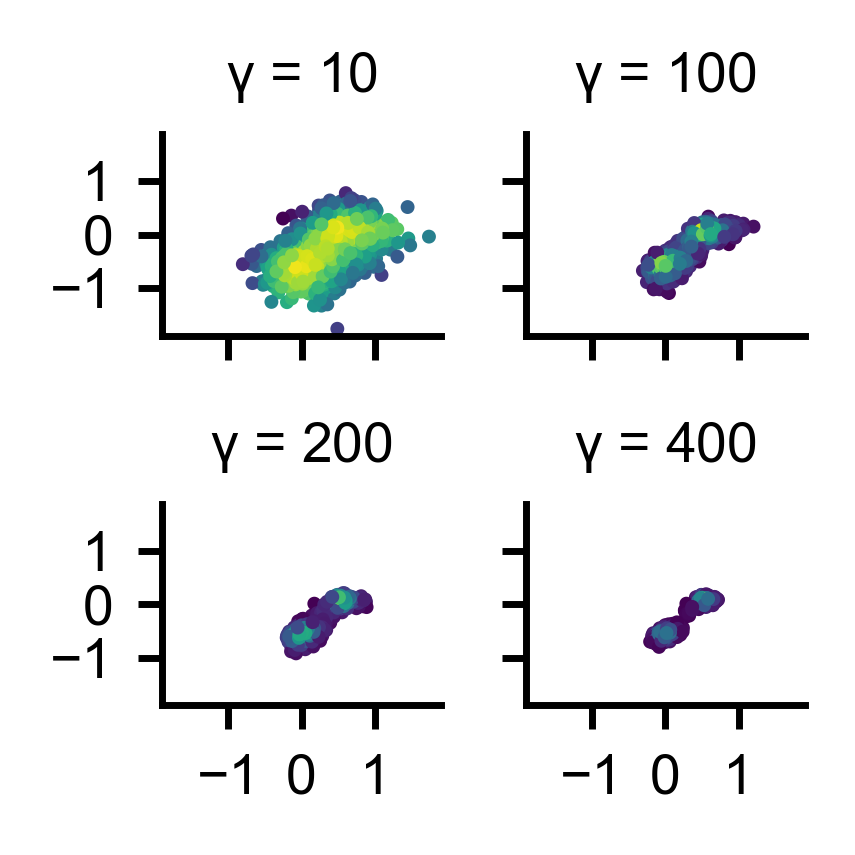

In [28]:
fig, axs = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(3.5 / 2, 3.5 / 2))

for idx, ax in enumerate(axs.flatten()):
    ax.set_title(fr"$\gamma$ = {betas[idx]}")           
    ax.scatter(*samples[idx].T, s=1, c=np.exp(p[idx]))

ax.set_xlim([-1.9, 1.9])
ax.set_ylim([-1.9, 1.9])
# fig.suptitle("Two Moons: GBI-Diff")
fig.tight_layout()
fig.savefig("figures/theta_samples_gbi_diff.pdf")

In [11]:
sampler.update_gamma(8000)
samples = sampler.forward(1000).detach()

Sample in observed data: 100%|██████████| 10/10 [00:49<00:00,  4.95s/it]


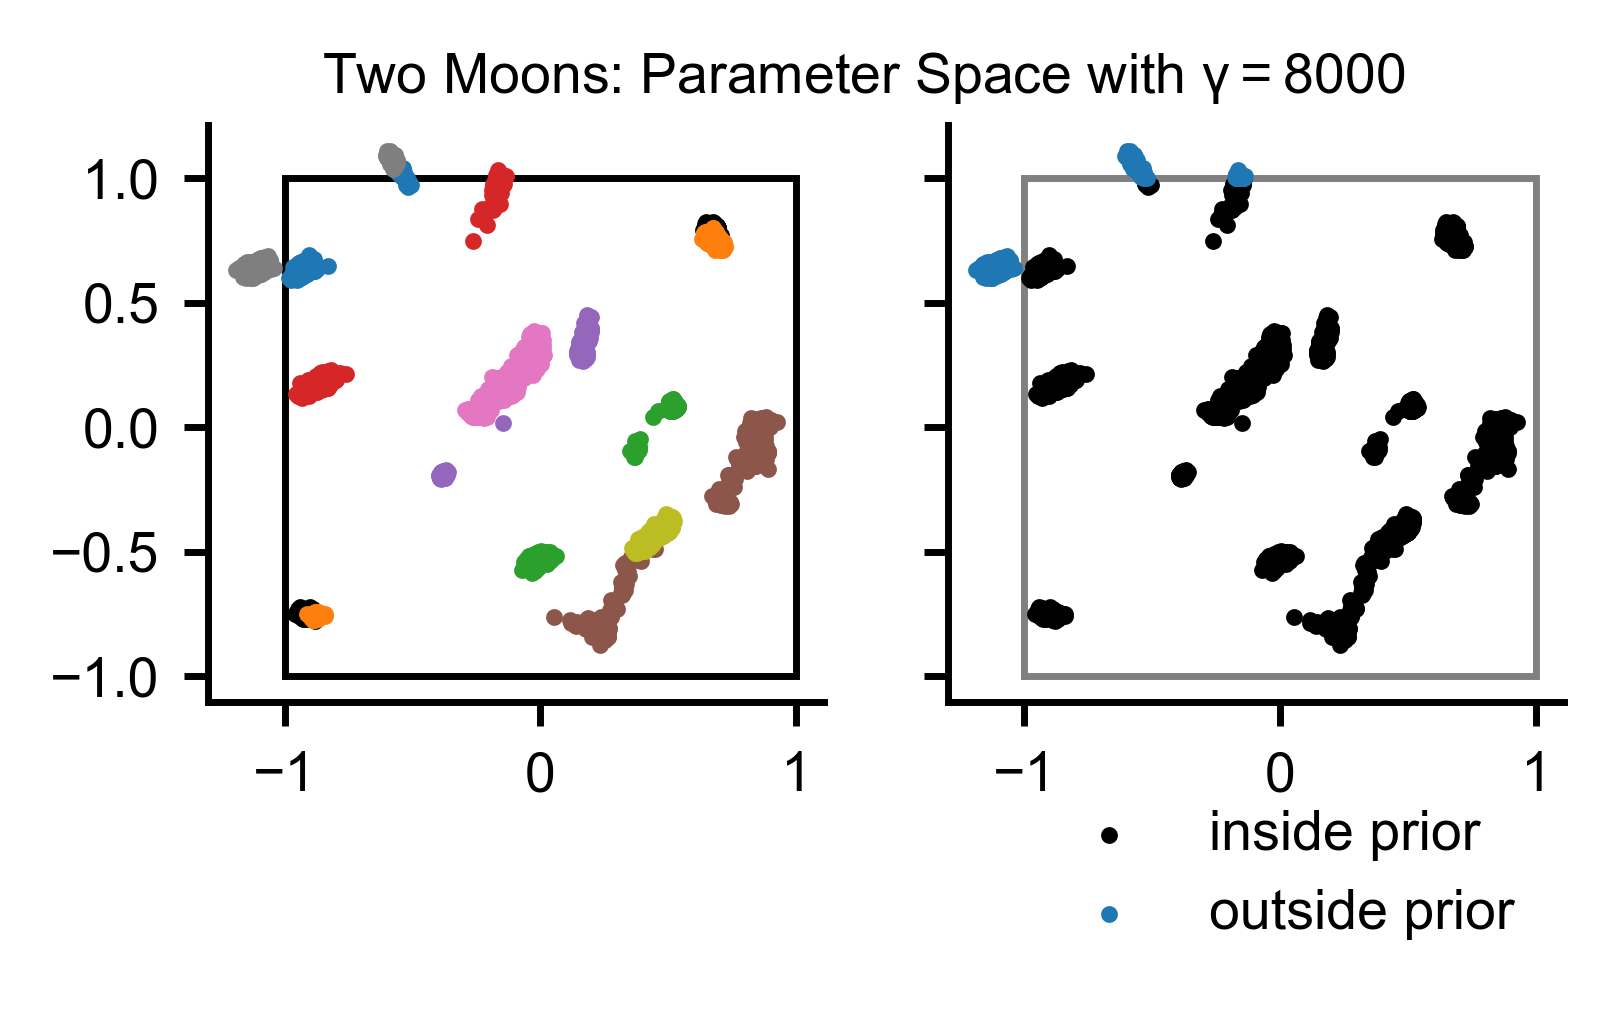

In [ ]:
def in_rectangle(samples: Tensor, corrds: Tensor, stretch: Tensor) -> Tensor:
    """_summary_

    Args:
        samples (Tensor): (n_samples, feature_dim)
        corrds (Tensor): minimum corner (feature_dim, )
        stretch (Tensor): maximum corner (feature_dim, )

    Returns:
        Tensor: binary mask (n_samples, )
    """
    assert (stretch >= 0).prod(), "all elements of stretch have to be greater equal 0"
    mask = (samples >= corrds) * (samples <= (corrds + stretch))
    mask = torch.prod(mask, dim=-1).bool()
    return mask


fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(3.5, 1.5))
ax1.set_aspect("auto")
ax2.set_aspect("auto")

rect = patches.Rectangle((-1, -1), 2, 2, linewidth=1, edgecolor='k', facecolor='none')
ax1.add_patch(rect)    
rect = patches.Rectangle((-1., -1.), 2., 2., linewidth=1, edgecolor='grey', facecolor='none')
ax2.add_patch(rect)    
for sample_idx in range(samples.shape[0]):
    ax1.scatter(*samples[sample_idx].T, s=2)

mask = in_rectangle(samples, torch.tensor((-1, -1)), torch.tensor([2, 2]))
ax2.scatter(*samples[mask].T, s=2, label="inside prior")
ax2.scatter(*samples[~mask].T, s=2, label="outside prior")
ax2.legend(bbox_to_anchor=(1, -0.2), ncols=1)
ax1.set_xlabel(r"x_1")
ax1.set_ylabel(r"x_2")
ax2.set_ylabel(r"x_1")
fig.suptitle(r"Two Moons: Parameter Space with $\gamma=8000$")
fig.savefig("figures/pushing_inverse_temperature_two_moons.pdf")

(tensor(0.4691), tensor(1.0761))

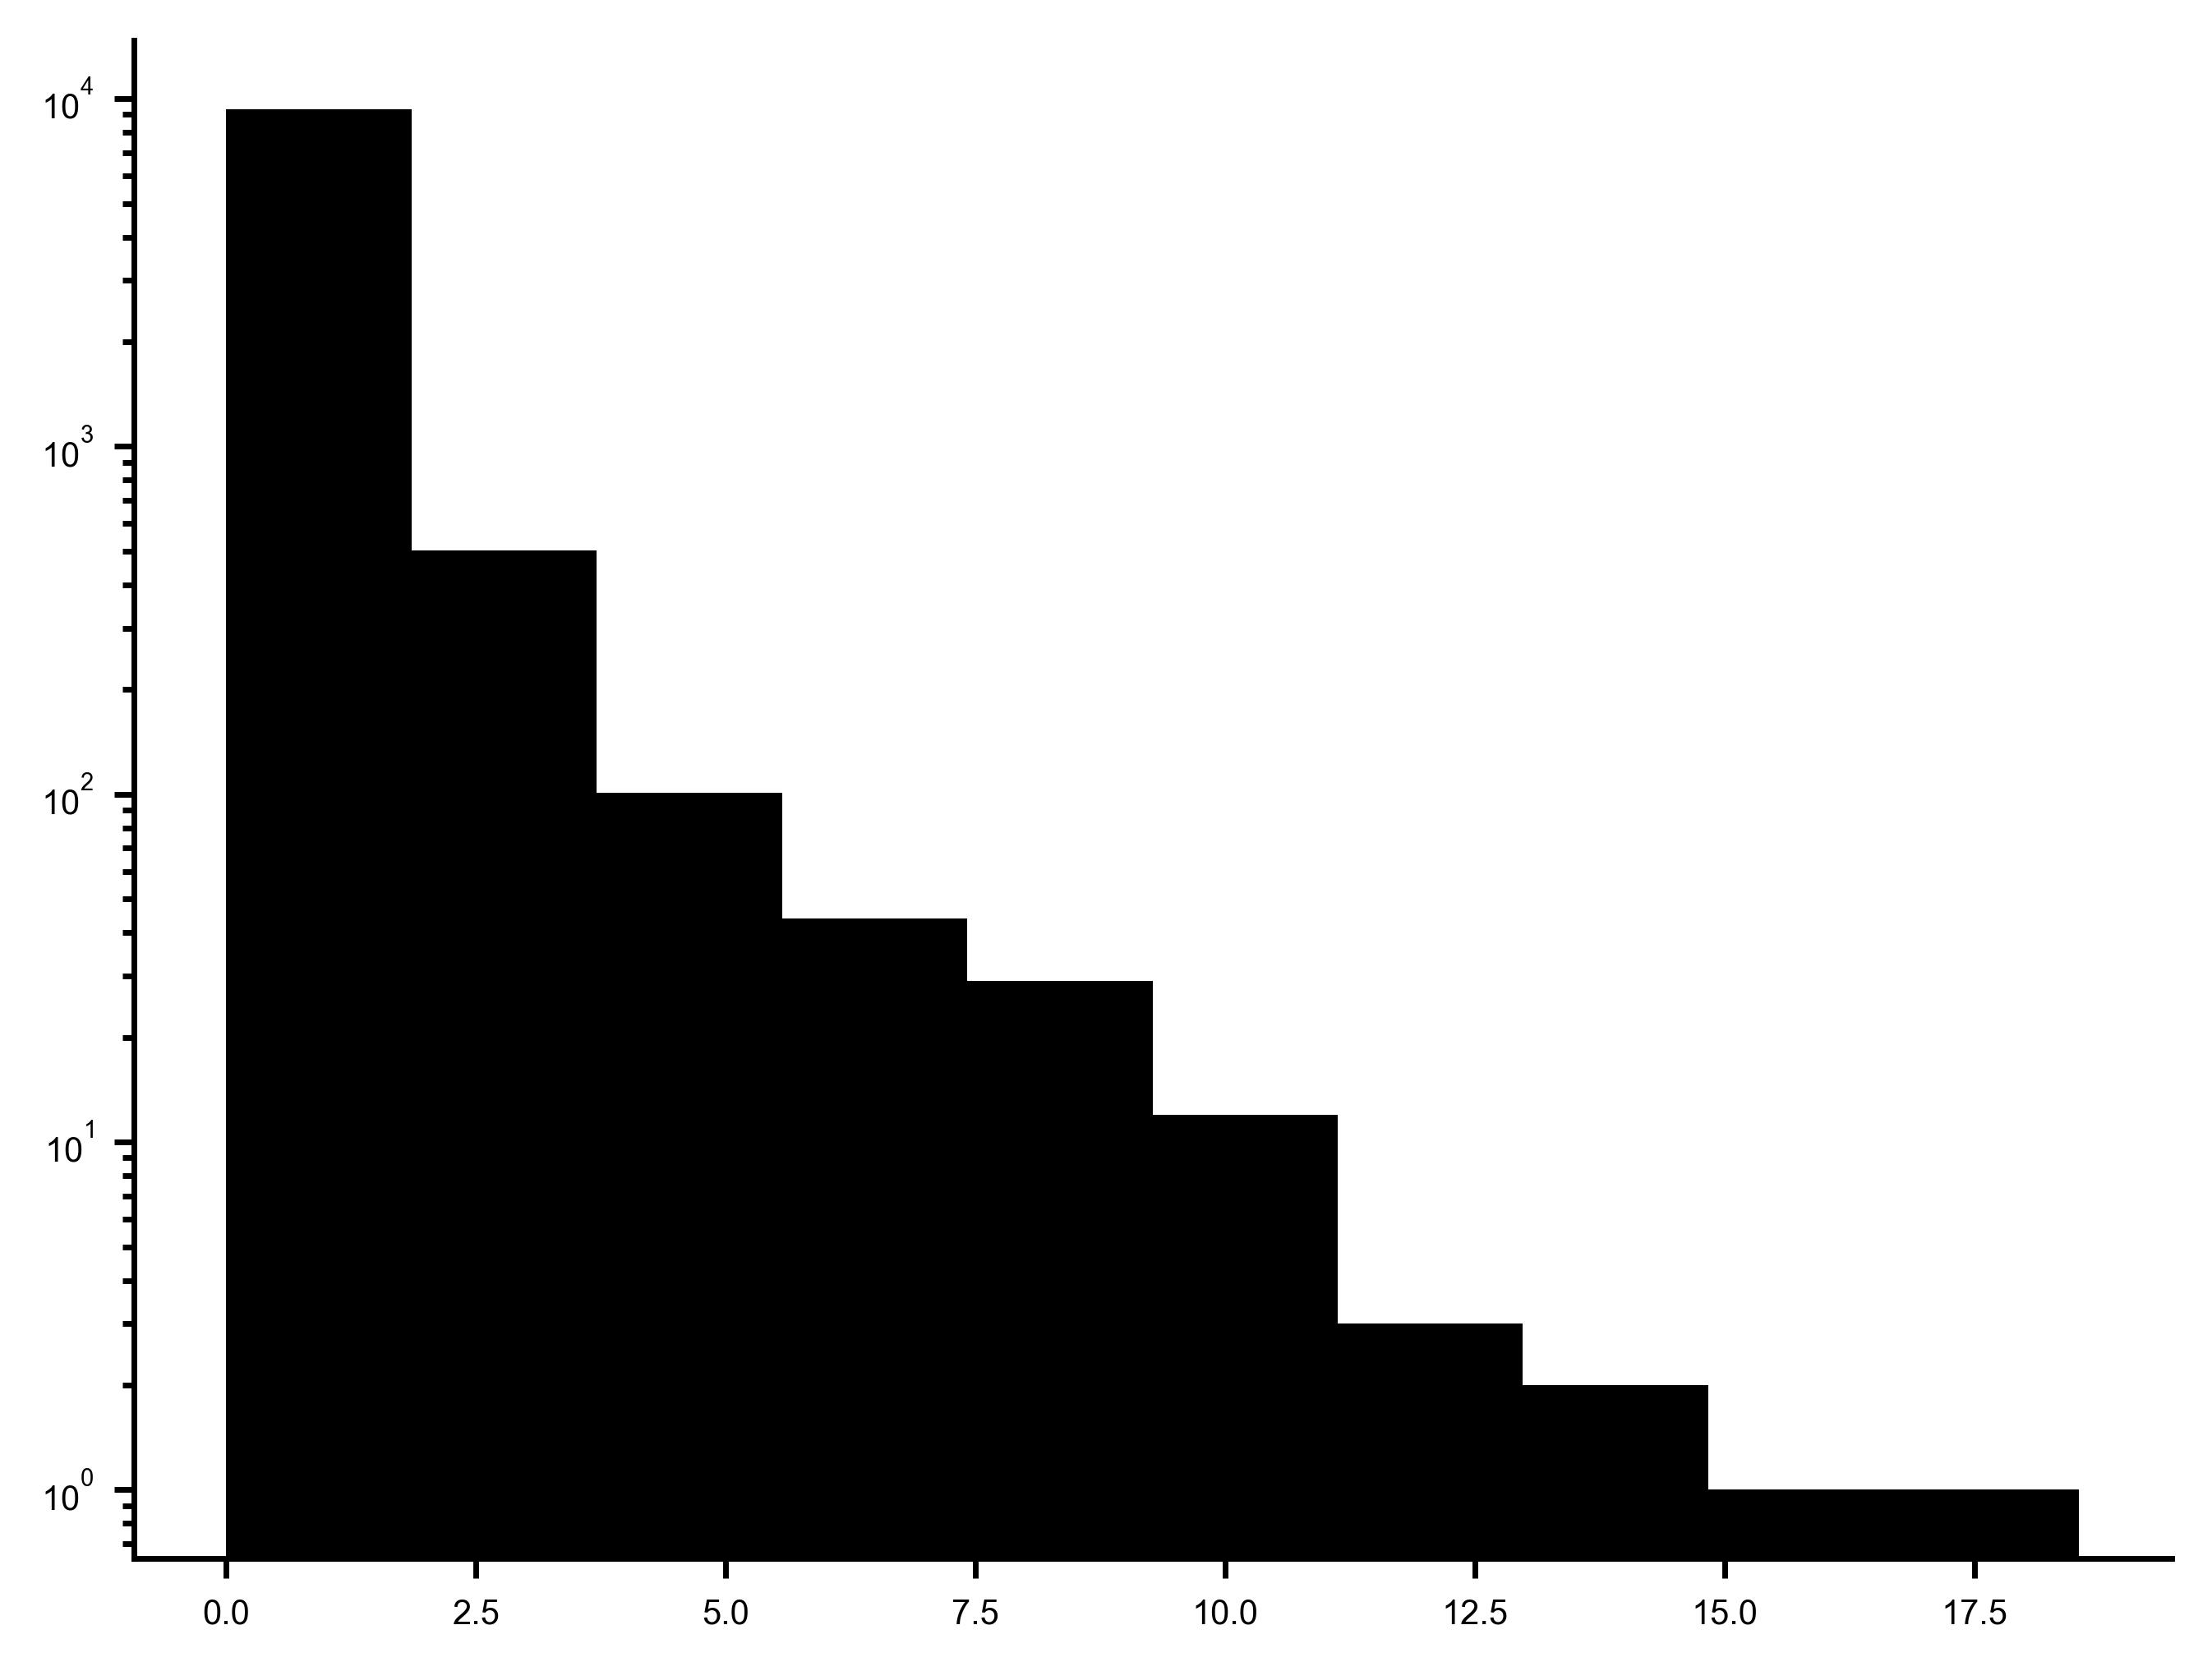

In [ ]:
from gbi_diff.dataset.dataset import TwoMoons

posterior_samples = TwoMoons().sample_posterior(torch.concat([*samples], dim=0))
diff = torch.square(posterior_samples - torch.repeat_interleave(sampler.x_o, 1000, 0)).mean(dim=-1)
plt.hist(diff)
plt.yscale("log")
diff.mean(), diff.std() 

# 1000 (tensor(0.0223), tensor(0.0268)) 
# 2000 (tensor(-0.0343), tensor(0.1872))
# 4000 (tensor(0.1571), tensor(0.8983))

/tmp/ipykernel_327415/1828716241.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([None, *(np.linspace(0, 1, 5)[::-1] * 1000).astype(int)])


torch.Size([10, 1001, 1000, 2])
torch.Size([10, 1000, 1000])
torch.Size([8728, 1000])


Text(0.5, 0, 'Diffusion Time')

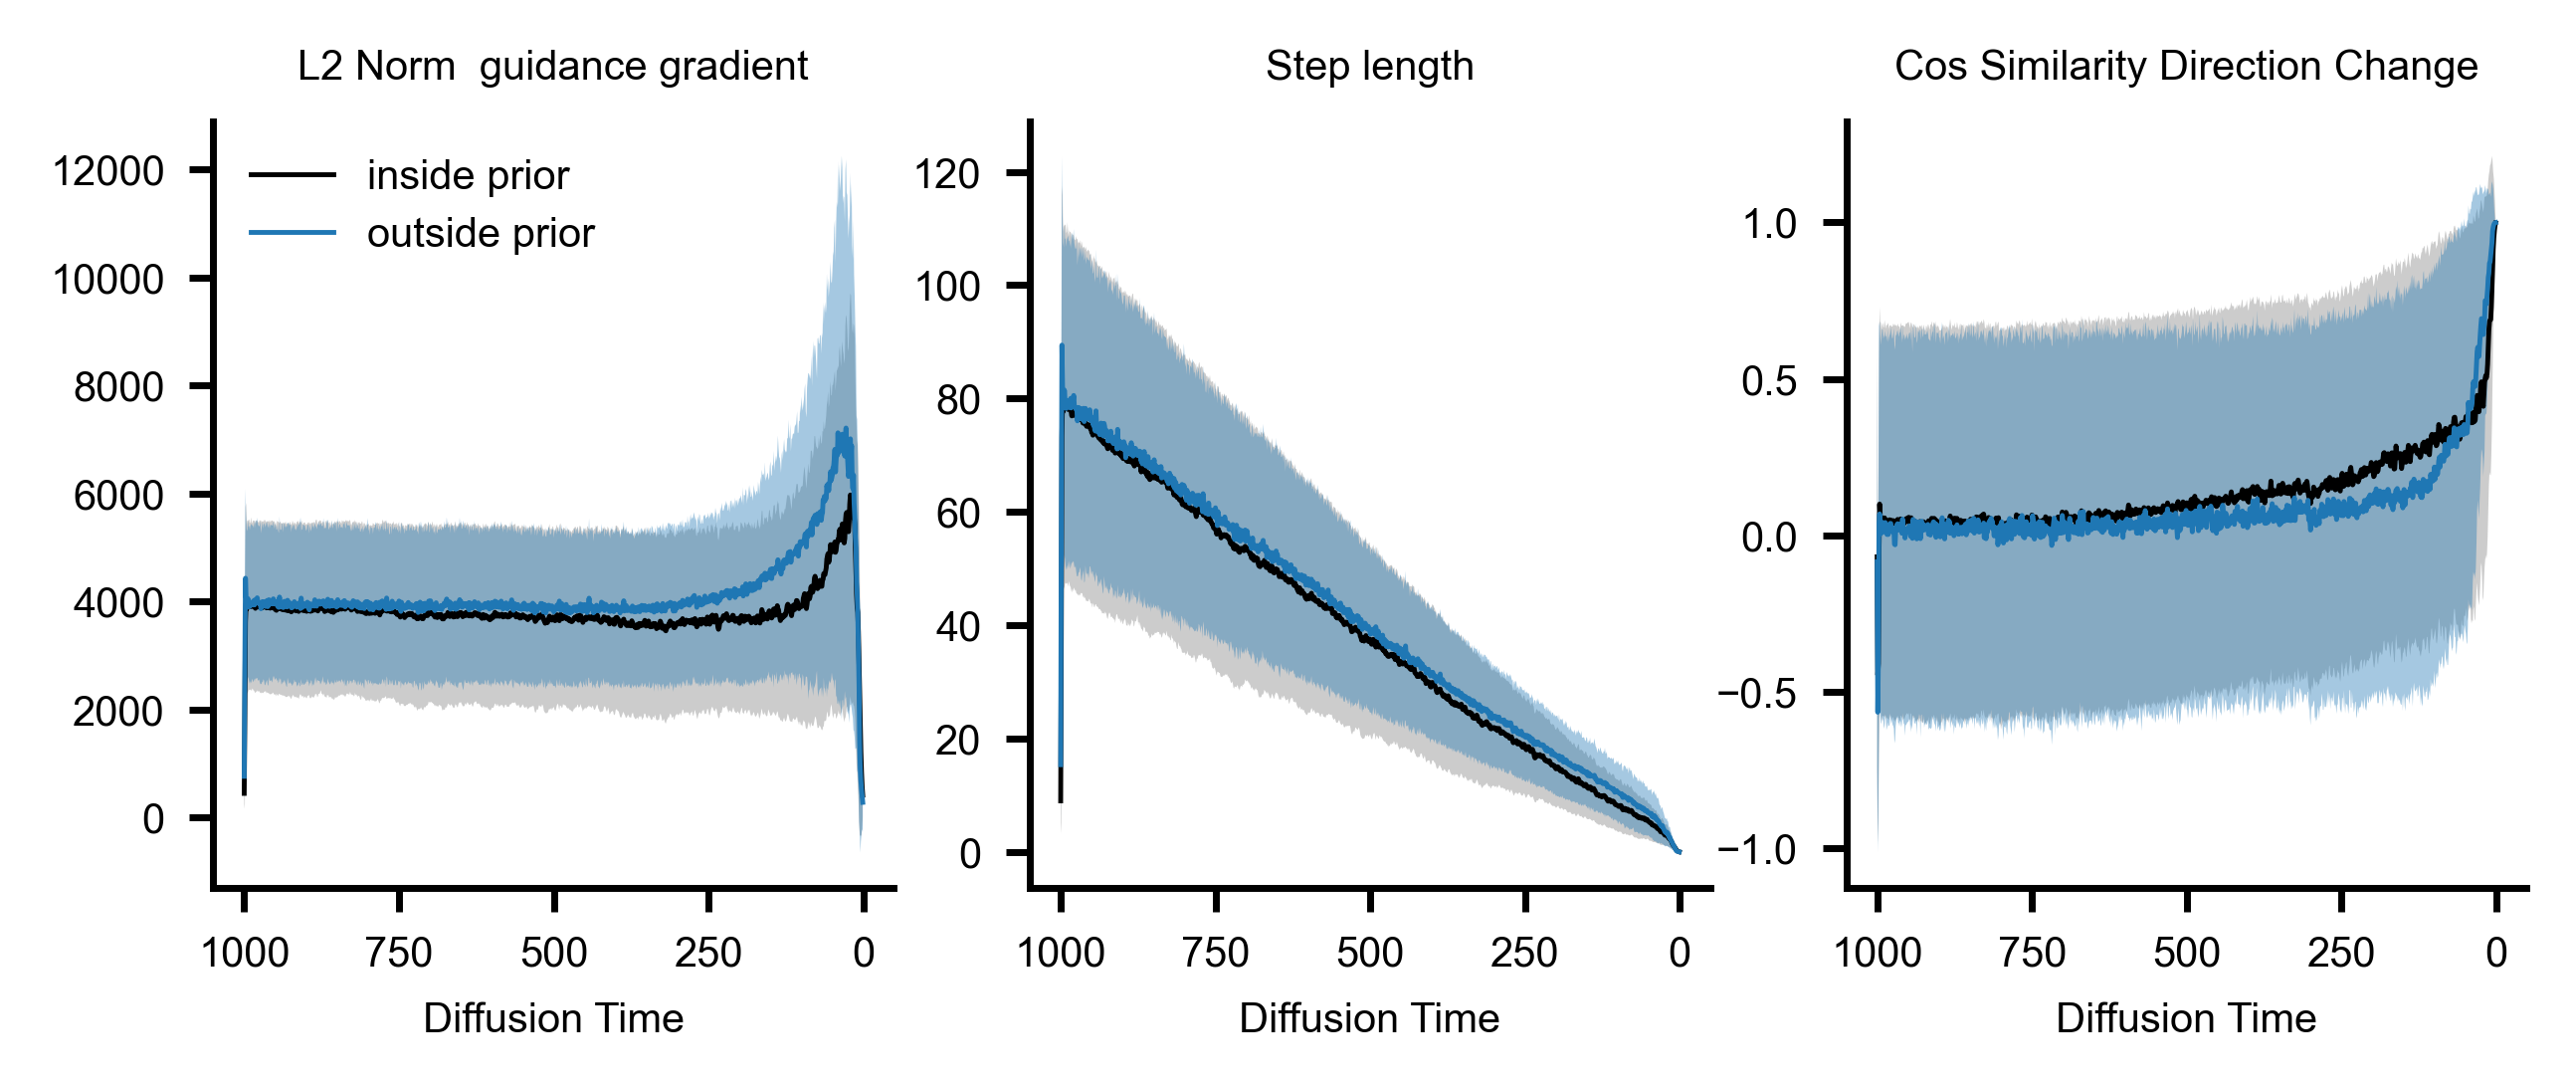

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharex=True, figsize=(6, 2))
ax1.set_xticklabels([None, *(np.linspace(0, 1, 5)[::-1] * 1000).astype(int)])
ax1.set_title("L2 Norm  guidance gradient")

guidance_grads = sampler._info["guidance_grad"]
guidance_stats = torch.linalg.norm(guidance_grads, dim=-1)
guidance_stats = guidance_stats.swapdims(1, 2)

ax1.fill_between(
    range(1000),
    guidance_stats[mask].mean(dim=0) - guidance_stats[mask].std(dim=0),
    guidance_stats[mask].mean(dim=0) + guidance_stats[mask].std(dim=0),
    alpha=0.2,
)
ax1.plot(guidance_stats[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax1.fill_between(
    range(1000),
    guidance_stats[~mask].mean(dim=0) - guidance_stats[~mask].std(dim=0),
    guidance_stats[~mask].mean(dim=0) + guidance_stats[~mask].std(dim=0),
    alpha=0.4,
)                       
ax1.plot(guidance_stats[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax1.set_xlabel("Diffusion Time")
ax1.legend()

trajectory = sampler._info["trajectory"]
step_length = torch.linalg.norm(torch.diff(trajectory, dim=1), dim=-1)
step_length = step_length.swapdims(1, 2)

ax2.fill_between(
    range(1000),
    step_length[mask].mean(dim=0) - step_length[mask].std(dim=0),
    step_length[mask].mean(dim=0) + step_length[mask].std(dim=0),
    alpha=0.2,
)
ax2.plot(step_length[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax2.fill_between(
    range(1000),
    step_length[~mask].mean(dim=0) - step_length[~mask].std(dim=0),
    step_length[~mask].mean(dim=0) + step_length[~mask].std(dim=0),
    alpha=0.4,
)
ax2.plot(step_length[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax2.set_xlabel("Diffusion Time")
ax2.set_title("Step length")

print(trajectory.shape)
traj_dir_change = (
    torch.sum(trajectory[:, :-1] * trajectory[:, 1:], dim=-1)
    / torch.linalg.norm(trajectory[:, :-1], dim=-1)
    / torch.linalg.norm(trajectory[:, 1:], dim=-1)
)
# traj_dir_change = torch.arccos(traj_dir_change)
print(traj_dir_change.shape)
traj_dir_change = traj_dir_change.swapdims(1, 2)
print(traj_dir_change[mask].shape)
ax3.fill_between(
    range(1000),
    traj_dir_change[mask].mean(dim=0) - traj_dir_change[mask].std(dim=0),
    traj_dir_change[mask].mean(dim=0) + traj_dir_change[mask].std(dim=0),
    alpha=0.2,
)
# ax3.plot(traj_dir_change[mask].T, linewidth=0.1, color="k")
# ax3.plot(traj_dir_change[~mask].T, linewidth=0.5, color=colors_tab10(0))
ax3.plot(traj_dir_change[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax3.fill_between(
    range(1000),
    traj_dir_change[~mask].mean(dim=0) - traj_dir_change[~mask].std(dim=0),
    traj_dir_change[~mask].mean(dim=0) + traj_dir_change[~mask].std(dim=0),
    alpha=0.4,
)
ax3.plot(traj_dir_change[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax3.set_title("Cos Similarity Direction Change")
ax3.set_xlabel("Diffusion Time")


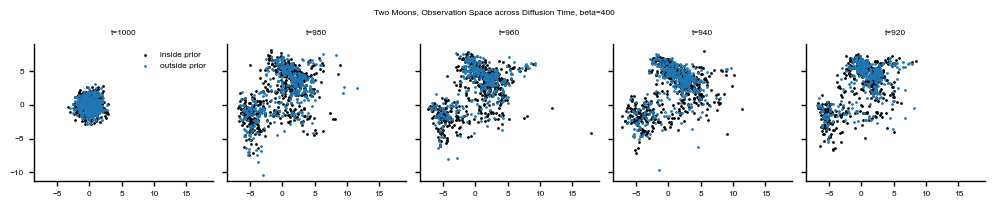

In [ ]:
sample_idx = 0
times = [0, 20, 40, 60, 80]
fig, axs = plt.subplots(ncols=len(times), sharex=True, sharey=True, figsize=(10, 2))
for idx, t in enumerate(times):
    axs[idx].scatter(*trajectory[sample_idx,t, mask[sample_idx]].T, s=1, label="inside prior")
    axs[idx].scatter(*trajectory[sample_idx,t, ~mask[sample_idx]].T, s=1, label="outside prior")
    axs[idx].set_title(f"t={1000 - t}")
axs[0].legend()
fig.suptitle("Two Moons, Observation Space across Diffusion Time, beta=400")
fig.tight_layout()


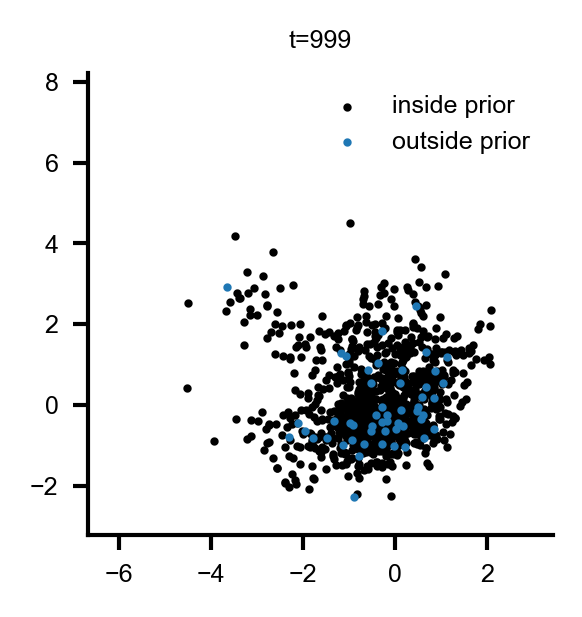

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots(figsize=(2, 2))
title = ax.set_title(f"t={1000}")
inside_scat = ax.scatter(
    *trajectory[sample_idx, 0, mask[sample_idx]].T, s=1, label="inside prior"
)
outside_scat = ax.scatter(
    *trajectory[sample_idx, 0, ~mask[sample_idx]].T, s=1, label="outside prior"
)

x_lim = (trajectory[sample_idx, ..., 0].min(), trajectory[sample_idx, ..., 0].max())
y_lim = (trajectory[sample_idx, ..., 1].min(), trajectory[sample_idx, ..., 1].max())
ax_x_lim = ax.set_xlim(x_lim)
ax_y_lim = ax.set_ylim(y_lim)
ax.legend()

def animate(t,):
    title.set_text(f"t={1000 - t}")
    inside_scat.set_offsets(trajectory[sample_idx, t, mask[sample_idx]])
    outside_scat.set_offsets(trajectory[sample_idx, t, ~mask[sample_idx]])
    return inside_scat, outside_scat


ani = FuncAnimation(fig, animate, repeat=True, frames=range(1, 1001) , interval=50)
writer = PillowWriter(fps=15, metadata=dict(artist="Me"), bitrate=1800)
ani.save("scatter.gif", writer=writer)

In [ ]:
diffusion_ckpt = "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_diffusion/two_moons/2025-03-27-01-38-46/lightning_logs/version_0/epoch=99-step=4000.ckpt"

config: Config = Config.from_file("../config/sampling_diffusion.yaml")
config.beta = 2000
sampler = DiffusionSampler(
    diffusion_ckpt, res_net_guidance_ckpt, config.observed_data_file, config.beta, False, extended_information=True
)
samples = sampler.forward(100)


Sample in observed data: 100%|██████████| 10/10 [00:24<00:00,  2.44s/it]
